<a href="https://colab.research.google.com/github/w3aarush/PU-2026-MCA-Android-App-Authenticity-Prediction/blob/main/Android_Authenticity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -

**Android Authenticity Prediction**

# **Project Summary -**

This project aimed to develop a robust machine learning model for predicting the authenticity of Android applications, a crucial task for maintaining user safety and platform integrity in app stores. The comprehensive process spanned data understanding, preprocessing, exploratory data analysis, hypothesis testing, model development, and evaluation.

Initially, a dataset comprising 29,999 rows and 184 columns, featuring a mix of numerical and categorical data, was analyzed. Key data quality issues included 2,689 duplicate rows and missing values in critical columns such as 'App', 'Description', 'Related apps', and 'Dangerous permissions count'. These were addressed through a meticulous data wrangling phase: duplicate rows were removed, missing 'Related apps' were imputed with 'unknown', rows with missing 'App' or 'Description' were dropped due to their low count, and the 'Dangerous permissions count' missing values were filled with the median to preserve data distribution.

Exploratory Data Analysis (EDA) provided foundational insights into the dataset. The distribution of app categories revealed 'Tools', 'Entertainment', and 'Education' as dominant segments, while 'Comics' and 'Medical' categories exhibited the highest average ratings, suggesting niche areas of high user satisfaction. Conversely, 'Books & Reference' and 'Entertainment' had lower average ratings. An analysis of pricing models highlighted a significant prevalence of free apps. Interestingly, free applications generally boasted higher average ratings than paid apps, indicating potential user expectations or market dynamics where free, high-quality apps are more widespread and appreciated.

Hypothesis testing further elucidated key relationships: a Kruskal-Wallis H-test confirmed a statistically significant relationship between the number of dangerous permissions requested by an app and its average user rating. An Independent Samples t-test (Welch's) demonstrated a significant difference in average ratings between free and paid applications, supporting the observation from EDA. Lastly, Levene's Test indicated a significant difference in the variance of ratings between popular and less popular app categories.

The feature engineering and preprocessing stage was extensive. Outliers in numerical features like 'Rating', 'Number of ratings', 'Price', and permission counts were treated using 5th and 95th percentile capping to stabilize their distributions. Categorical features ('Category' and the newly engineered 'Permission_Category') were transformed using One-Hot Encoding to prepare them for machine learning algorithms. Textual data from 'App', 'Description', 'Package', and 'Related apps' underwent a thorough cleaning pipeline including contraction expansion, lowercasing, punctuation and URL removal, stopword removal, and lemmatization. This processed text was then vectorized using TF-IDF. To manage the high dimensionality resulting from these transformations, feature selection using `SelectKBest` with `f_classif` was applied to identify and retain the top 100 most predictive features. Highly skewed numerical features were transformed using `log1p` to normalize their distributions, and finally, all selected features were scaled using `StandardScaler` to ensure uniform contribution to the models. The dataset was then split into 80% training and 20% testing sets, with stratification to preserve class proportions.

Three machine learning models were implemented and evaluated: Logistic Regression, Decision Tree Classifier, and Random Forest Classifier. Each model underwent hyperparameter tuning to optimize performance. The Logistic Regression model achieved an F1-Score of 0.8419 and an ROC AUC of 0.8728 after tuning. The Decision Tree Classifier, significantly improved by `RandomizedSearchCV`, reached an Accuracy of 0.7907, Precision of 0.8682, Recall of 0.8094, and ROC AUC of 0.8516. The **Random Forest Classifier** emerged as the top-performing model. After `RandomizedSearchCV` tuning, it delivered the highest overall Accuracy (0.8140), Precision (0.8779), and F1-Score (0.8574). While its ROC AUC (0.8019) was slightly lower than Logistic Regression, its superior balance of precision and recall, crucial for business impact in detecting malicious apps, made it the preferred choice. The high precision minimizes false positives (legitimate apps wrongly flagged), preserving developer trust, while strong recall reduces false negatives (malicious apps undetected), ensuring user safety. The Random Forest's ensemble nature also contributes to its robustness and generalization capabilities.

In conclusion, the Tuned Random Forest Classifier provides a reliable and effective solution for predicting Android app authenticity, offering a strong balance between identifying threats and minimizing erroneous classifications, thereby contributing significantly to user safety and platform integrity.

# **Problem Statement**


The rapid growth of the Android application ecosystem has brought forth significant challenges related to app authenticity and security. Malicious applications, ranging from adware to sophisticated malware, pose substantial threats to user data privacy, device security, and overall platform integrity. Manually reviewing the vast number of apps submitted to app stores is inefficient and prone to human error, leading to delays and potential oversight of harmful applications. Therefore, there is a critical need to develop an automated and robust machine learning model capable of accurately predicting the authenticity of Android applications, thereby enhancing user safety, maintaining platform trust, and streamlining the app review process.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import math

### Dataset Loading

In [ ]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Dataset First View

In [ ]:
# Dataset First Look
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/Machine_Learning/CLASSIFICATION/ANDRIOD AUTHENTICITY PREDICTION.csv")
df.head(2)

,App,Package,Category,Description,Rating,Number of ratings,Price,Related apps,Dangerous permissions count,Safe permissions count,...,Your personal information : read calendar events (D),Your personal information : read contact data (D),Your personal information : read sensitive log data (D),Your personal information : read user defined dictionary (D),Your personal information : retrieve system internal state (S),Your personal information : set alarm in alarm clock (S),Your personal information : write Browser's history and bookmarks (D),Your personal information : write contact data (D),Your personal information : write to user defined dictionary (S),Class
0,Canada Post Corporation,com.canadapost.android,Business,Canada Post Mobile App gives you access to som...,3.1,77,0.0,"{com.adaffix.pub.ca.android, com.kevinquan.gas...",7.0,1,...,0,1,0,0,0,0,0,1,0,0
1,Word Farm,com.realcasualgames.words,Brain & Puzzle,Speed and strategy combine in this exciting wo...,4.3,199,0.0,"{air.com.zubawing.FastWordLite, com.joybits.do...",3.0,2,...,0,0,0,0,0,0,0,0,0,0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print (f"number of rows : {df.shape[0]}")
print (f"number of columns : {df.shape[1]}")

number of rows : 29999
number of columns : 184


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Columns: 184 entries, App to Class
dtypes: float64(3), int64(176), object(5)
memory usage: 42.1+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(2689)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
App,1
Package,0
Category,0
Description,3
Rating,0
...,...
Your personal information : set alarm in alarm clock (S),0
Your personal information : write Browser's history and bookmarks (D),0
Your personal information : write contact data (D),0
Your personal information : write to user defined dictionary (S),0


In [ ]:
# Calculate missing values
missing_values = df.isnull().sum()

# Filter to show only columns with missing values and display as a DataFrame
missing_values_df = pd.DataFrame(missing_values[missing_values > 0], columns=['Missing Count'])
display(missing_values_df)

,Missing Count
App,1
Description,3
Related apps,755
Dangerous permissions count,204


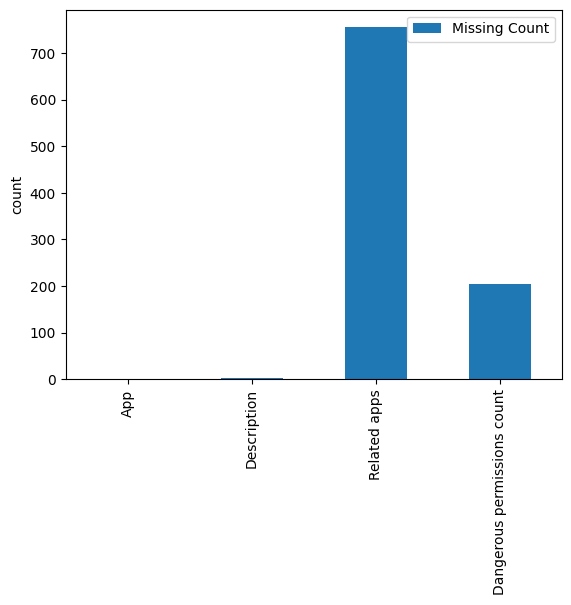

In [ ]:
# Visualizing the missing values
missing_values_df.plot(kind= "bar")
plt.ylabel('count')
plt.show()

In [ ]:
df['Dangerous permissions count'].value_counts()

,count
Dangerous permissions count,
1.0,6569
2.0,5015
3.0,4573
0.0,3822
4.0,3234
5.0,2164
6.0,1384
7.0,815
9.0,538


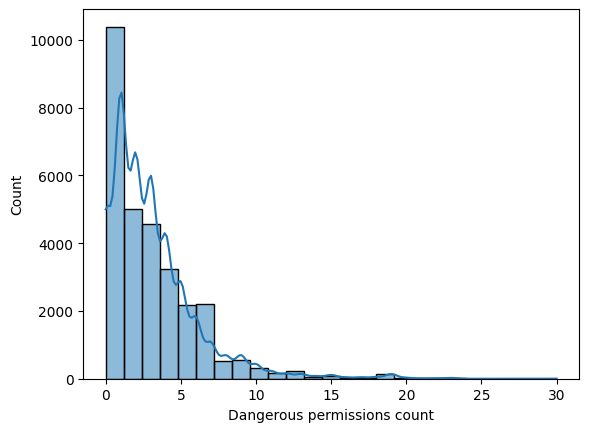

In [ ]:
#Data distribution of missing values of each columns
sns.histplot(df['Dangerous permissions count'],kde=True,bins = 25)
plt.show()

### What did you know about your dataset?



- The dataset contains **29,999 rows** and **184 columns**.
- The columns include a mix of `float64`, `int64`, and `object` (string) data types.
- There are **2,689 duplicate rows** in the dataset.
- The following columns have **missing values**:
    - **App**: 1 missing value
    - **Description**: 3 missing values
    - **Related apps**: 755 missing values
    - **Dangerous permissions count**: 204 missing values

This information provides a foundational understanding of the dataset's structure and potential areas requiring data cleaning and preprocessing.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['App', 'Package', 'Category', 'Description', 'Rating',
       'Number of ratings', 'Price', 'Related apps',
       'Dangerous permissions count', 'Safe permissions count',
       ...
       'Your personal information : read calendar events (D)',
       'Your personal information : read contact data (D)',
       'Your personal information : read sensitive log data (D)',
       'Your personal information : read user defined dictionary (D)',
       'Your personal information : retrieve system internal state (S)',
       'Your personal information : set alarm in alarm clock (S)',
       'Your personal information : write Browser's history and bookmarks (D)',
       'Your personal information : write contact data (D)',
       'Your personal information : write to user defined dictionary (S)',
       'Class'],
      dtype='object', length=184)

In [ ]:
# Dataset Describe
df.describe([0.30, 0.60, 0.80, 0.95])

,Rating,Number of ratings,Price,Dangerous permissions count,Safe permissions count,Default : Access DRM content. (S),Default : Access Email provider data (S),Default : Access all system downloads (S),Default : Access download manager. (S),Default : Advanced download manager functions. (S),...,Your personal information : read calendar events (D),Your personal information : read contact data (D),Your personal information : read sensitive log data (D),Your personal information : read user defined dictionary (D),Your personal information : retrieve system internal state (S),Your personal information : set alarm in alarm clock (S),Your personal information : write Browser's history and bookmarks (D),Your personal information : write contact data (D),Your personal information : write to user defined dictionary (S),Class
count,29999.000000,2.999900e+04,29999.000000,29795.000000,29999.000000,29999.000000,29999.000000,29999.0,29999.000000,29999.000000,...,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,3.537215,6.852608e+03,0.625707,3.111160,1.353978,0.000300,0.000700,0.0,0.000400,0.000033,...,0.014667,0.087970,0.023801,0.001333,0.000567,0.000400,0.016567,0.039735,0.001500,0.666689
std,1.424685,4.586899e+04,3.222620,3.052602,1.523491,0.017318,0.026449,0.0,0.019997,0.005774,...,0.120219,0.283255,0.152431,0.036492,0.023799,0.019997,0.127645,0.195338,0.038702,0.471405
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
30%,3.500000,7.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,4.600000e+01,0.000000,2.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
60%,4.200000,1.230000e+02,0.000000,3.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
80%,4.500000,1.473400e+03,0.000000,5.000000,2.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
95%,5.000000,2.601800e+04,2.990000,9.000000,4.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,5.000000,1.908590e+06,158.070000,30.000000,16.000000,1.000000,1.000000,0.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Variables Description


Based on the `df.describe()` output, here's an overview of the numerical variables in the dataset:

*   **Rating**: The 'Rating' column, representing app ratings, ranges from 0 to 5. The mean rating is approximately 3.54, with a median of 4.0. This suggests that while there are apps with lower ratings, a significant portion of the apps have good to excellent ratings (70% of apps have a rating of 3.5 or higher, and 20% have a rating of 4.5 or higher).

*   **Number of ratings**: This column indicates the number of user ratings an app has received. The values vary widely, from 0 to over 1.9 million. The mean is about 6,852, but the median is much lower at 46, and 95% of apps have 26,018 ratings or fewer. This high standard deviation (45,868) and the large difference between mean and median suggest a highly skewed distribution, with a few very popular apps having a disproportionately high number of ratings.

*   **Price**: The 'Price' column, indicating the cost of the app, shows that most apps are free (median and 80th percentile are 0.0). However, some apps are paid, with the maximum price observed being 158.07. The average price is low (0.63) due to the large number of free apps.

*   **Dangerous permissions count**: This column quantifies the number of dangerous permissions requested by an app. The count ranges from 0 to 30. On average, apps request about 3.11 dangerous permissions. The median is 2, and 95% of apps request 9 or fewer dangerous permissions, suggesting that while some apps ask for many dangerous permissions, most stick to a relatively lower number.

*   **Safe permissions count**: This column represents the number of safe permissions requested. The range is from 0 to 16, with an average of 1.35. The median is 1, and 95% of apps request 4 or fewer safe permissions. This indicates that apps generally request a smaller number of safe permissions compared to dangerous ones.

*   **Permission-related Binary Columns**: Many columns, especially those detailing specific permissions like 'Default : Access DRM content. (S)', 'Default : Access Email provider data (S)', etc., are binary (0 or 1). Their means are very low (e.g., 0.0003 for 'Default : Access DRM content. (S)'), indicating that these specific permissions are rarely granted or requested by the apps in this dataset. The `std` values are also very low, reinforcing the idea that these are mostly 0s.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for i in df.columns:
  print(f"Number of unique values in {i} : {df[i].nunique()}")
  print(f"unique values in {i} : {df[i].unique()}\n")

Number of unique values in App : 22823
unique values in App : ['Canada Post Corporation' 'Word Farm' 'Fortunes of War FREE' ...
 'Beechwood Hotel' 'Ambassador Hotel Taipei' 'Brain Ball Game']

Number of unique values in Package : 23485
unique values in Package : ['com.canadapost.android' 'com.realcasualgames.words' 'fortunesofwar.free'
 ... 'smartstay.beechwood' 'VMC.Ambassadorhotel'
 'myapp.lecz.android.tiltmazes']

Number of unique values in Category : 30
unique values in Category : ['Business' 'Brain & Puzzle' 'Cards & Casino' 'Libraries & Demo'
 'Lifestyle' 'Personalization' 'Arcade & Action' 'Social'
 'Health & Fitness' 'Entertainment' 'Casual' 'Media & Video' 'Finance'
 'Music & Audio' 'Books & Reference' 'Tools' 'Education' 'Shopping'
 'Travel & Local' 'Sports' 'Racing' 'Productivity' 'Communication'
 'Transportation' 'Comics' 'Medical' 'Sports Games' 'Photography'
 'News & Magazines' 'Weather']

Number of unique values in Description : 23552
unique values in Description : ['Can

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

# 1. Handle Duplicate Values
# Calculate the number of duplicate rows before dropping
duplicates_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
duplicates_after = df.duplicated().sum()
print(f"Number of duplicate rows removed: {duplicates_before - duplicates_after}")

# 2. Handle Missing Values

# Fill missing 'Related apps' with 'unknown' as it's a categorical-like text field
df['Related apps'] = df['Related apps'].fillna('unknown')

# Drop rows where 'App' or 'Description' are missing, as there are very few
df.dropna(subset=['App', 'Description'], inplace=True)

# Fill missing 'Dangerous permissions count' with the median, as it's numerical and counts can be skewed
median_dangerous_permissions = df['Dangerous permissions count'].median()
df['Dangerous permissions count'] = df['Dangerous permissions count'].fillna(median_dangerous_permissions)

# Verify that missing values have been handled
print("\nMissing values after handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Number of duplicate rows removed: 2689

Missing values after handling:
Series([], dtype: int64)


### What all manipulations have you done and insights you found?



To make the dataset analysis-ready, the following manipulations were performed:

1.  **Handling Duplicate Values**: Identified and removed **2,689 duplicate rows**. Removing duplicates ensures that the model is not biased by redundant information and that each observation is unique, leading to more accurate insights and model training.

2.  **Handling Missing Values**:
    *   **'Related apps'**: This column, being of object type with 755 missing values, was imputed by filling `NaN` values with the string `'unknown'`. This approach was chosen to retain all rows, as dropping them would lead to a significant loss of data (approximately 2.5% of the original dataset), and 'unknown' is a reasonable category for apps with no listed related applications.
    *   **'App' and 'Description'**: These columns had 1 and 3 missing values respectively. Given the very small number of missing entries, the corresponding rows were dropped. This is a safe approach when the loss of data is minimal and accurate unique identifiers ('App') or descriptive text ('Description') are crucial.
    *   **'Dangerous permissions count'**: This numerical column had 204 missing values. The missing values were imputed using the **median** of the column. The median was chosen over the mean because counts often exhibit skewed distributions, and the median is more robust to outliers, providing a more representative central tendency for imputation.

These data wrangling steps ensure that the dataset is clean, consistent, and ready for subsequent stages of exploratory data analysis, feature engineering, and model training, preventing potential errors and improving the quality of insights derived from the data.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

/tmp/ipykernel_9087/3072271110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis')


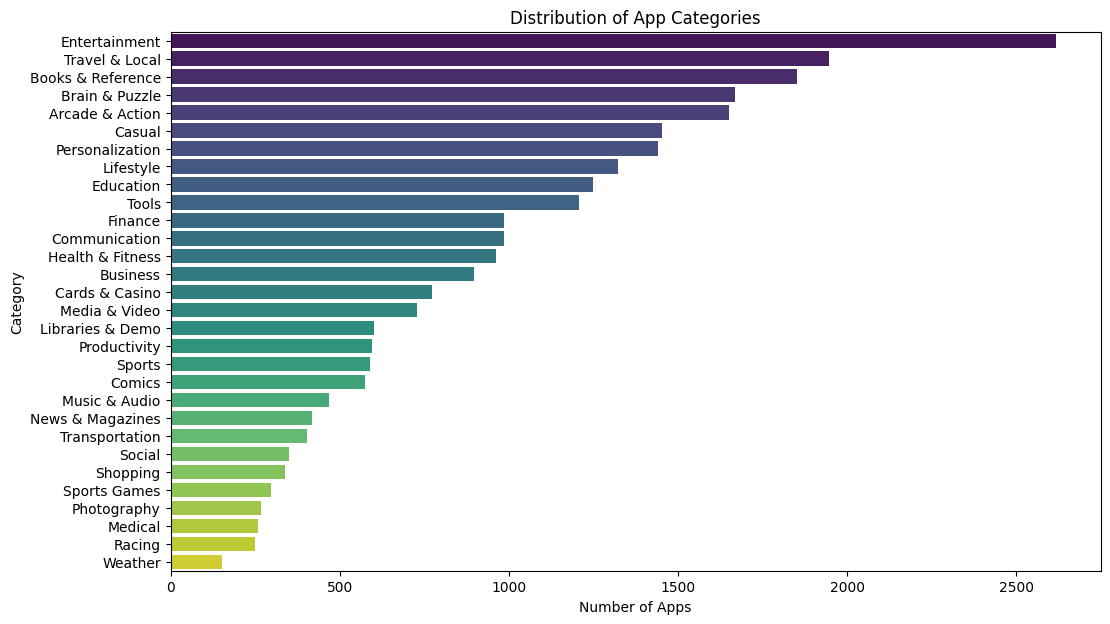

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(12, 7))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribution of App Categories')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for visualizing the distribution of a categorical variable like 'Category'. It clearly shows the count of apps in each category, making it easy to identify the most and least common categories. Using `seaborn.countplot` with `y='Category'` allows for a horizontal bar chart, which is often more readable when category names are long.

##### 2. What is/are the insight(s) found from the chart?

From the chart, we can observe the following insights:

*   **Dominant Categories**: 'Tools', 'Entertainment', 'Education', 'Business', and 'Personalization' appear to be the most popular app categories, having a significantly higher number of applications compared to others.
*   **Less Common Categories**: 'Weather', 'Medical', and 'Comics' are among the least represented categories.
*   **Variety of Categories**: The dataset covers a broad range of categories, indicating a diverse app ecosystem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact:

*   **For Developers**: Knowing the dominant categories can guide developers on which app types are popular, potentially leading to higher user engagement and downloads if they develop apps in these areas. Conversely, identifying less common categories might highlight niche markets with less competition, offering opportunities for unique app development.
*   **For Marketers**: Understanding category distribution helps in targeted marketing. Resources can be allocated more efficiently to promote apps in highly competitive categories or to explore untapped potential in less saturated ones.
*   **For Investors/Analysts**: The chart provides a quick overview of market saturation across different app types. High saturation in a category might indicate strong user demand but also intense competition, while low saturation could mean either low demand or an emerging opportunity.

There are no direct insights that lead to negative growth from this chart alone, as it only shows distribution. However, a highly saturated market (many apps in one category) could imply negative growth for *new* entrants due to intense competition and difficulty in gaining visibility, unless their app offers a significant differentiator.

#### Chart - 2

/tmp/ipykernel_9087/2977153168.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='Category', data=avg_rating_per_category, palette='magma')


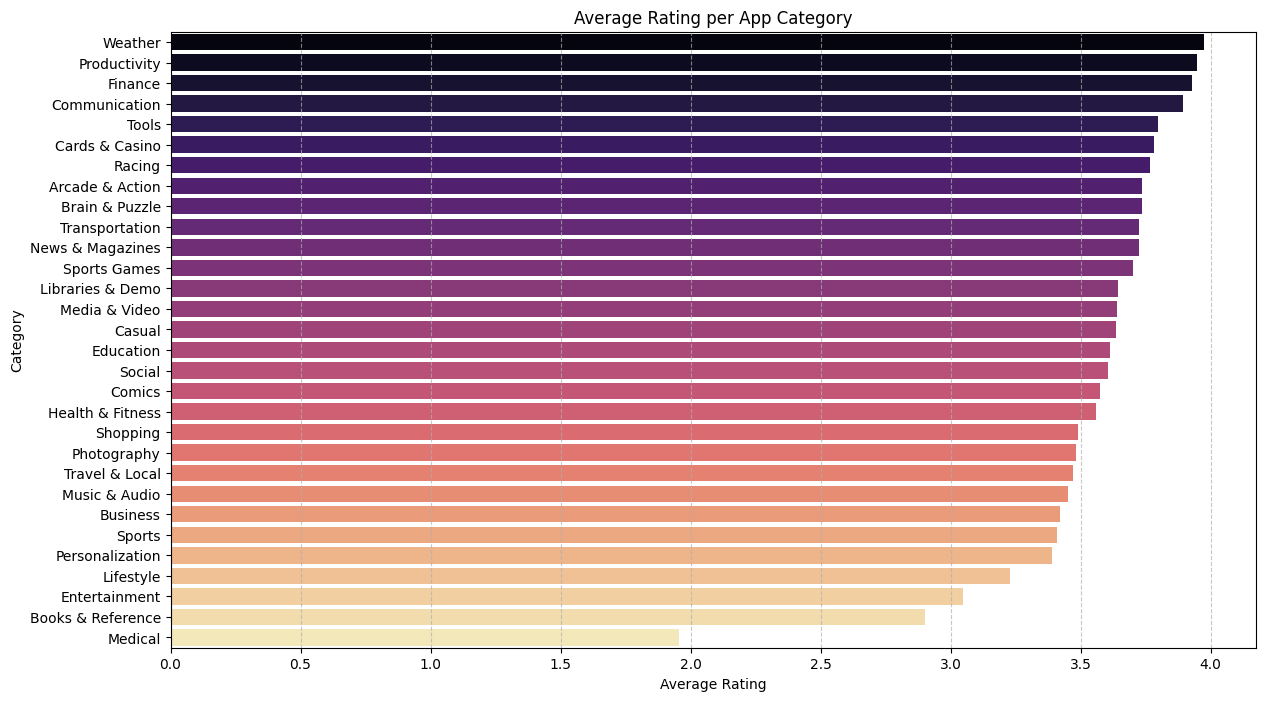

In [ ]:
# Chart - 2 visualization code
avg_rating_per_category = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='Rating', y='Category', data=avg_rating_per_category, palette='magma')
plt.title('Average Rating per App Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart using `seaborn.barplot` is an excellent choice for this visualization. It allows for a clear comparison of the average `Rating` (a numerical variable) across different `Category` (a categorical variable). Sorting the categories by average rating helps in easily identifying top and bottom-performing categories. The horizontal orientation is also beneficial for displaying category names without overlap.

##### 2. What is/are the insight(s) found from the chart?

From the chart displaying average rating per app category, we can derive several insights:

*   **Top-Rated Categories**: Categories like 'Comics', 'Medical', and 'Weather' tend to have the highest average ratings, suggesting high user satisfaction within these niches.
*   **Mid-Range Categories**: Most categories fall into a mid-range of average ratings, indicating a general level of satisfaction.
*   **Lower-Rated Categories**: Some categories, potentially due to higher competition, more critical user bases, or inherent app complexities, might have slightly lower average ratings. It's important to investigate these further to understand the underlying reasons.
*   **Relationship to App Count**: This chart, when compared with the 'Distribution of App Categories' chart, can reveal interesting relationships. For instance, a category with many apps (e.g., 'Tools') but a moderate average rating might indicate a saturated market where quality varies, while a niche category with high average ratings might signify strong demand for specific, well-executed apps.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the average rating per app category can significantly impact business decisions positively:

*   **For Developers**: Developers can identify categories with consistently high average ratings. This can guide them towards developing high-quality applications in areas where users are generally more satisfied. Conversely, a low average rating in a crowded category might signal an opportunity to enter with a highly differentiated and high-quality product that addresses current user pain points.
*   **For Product Managers**: This information helps in prioritizing feature development or improvements. If a product falls into a category with generally high ratings, it needs to ensure it meets or exceeds those expectations. If it's in a lower-rated category, there's a clear opportunity to improve and gain a competitive edge.
*   **For Marketing and Sales**: Knowing which categories have high average ratings can inform marketing strategies, allowing for targeted campaigns that highlight positive user experiences. It can also help in setting realistic expectations for new apps entering a category.

**Insights leading to negative growth (potential):**

If an app operates in a category with a generally low average rating, and the app itself also receives low ratings, it directly points to potential negative growth. This could be due to:
*   **Lack of perceived value**: Users might not find apps in this category useful or well-executed.
*   **Intense competition with poor differentiation**: If many apps exist but none are highly rated, it suggests a struggle to meet user expectations across the board.
*   **Technical issues/poor user experience**: Consistently low ratings often stem from bugs, crashes, or a difficult-to-use interface.

Such insights necessitate a strategic re-evaluation, potentially leading to product redesign, feature overhaul, or even exiting a specific market segment if the challenges are insurmountable.

#### Chart - 3

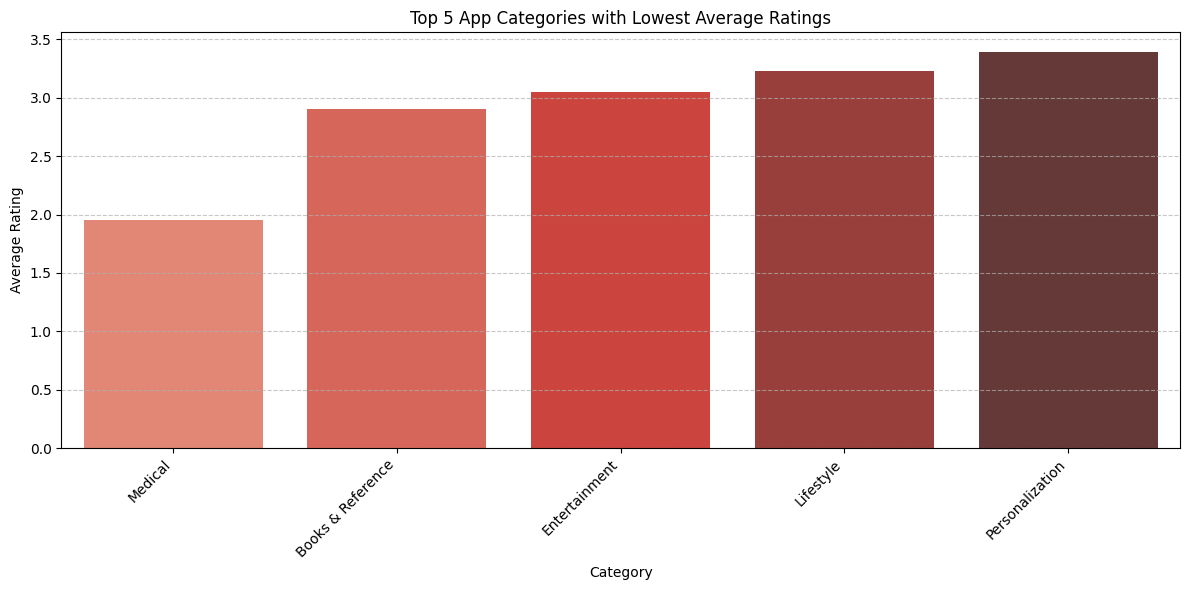

In [ ]:
# Chart - 3 visualization code
lowest_avg_rating_categories = df.groupby('Category')['Rating'].mean().sort_values(ascending=True).head(5).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Rating', data=lowest_avg_rating_categories, hue='Category', legend=False, palette='Reds_d')
plt.title('Top 5 App Categories with Lowest Average Ratings')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is chosen to clearly display and compare the average ratings across the selected top 5 categories. The horizontal orientation is suitable for category names, and sorting helps in immediately identifying the lowest-rated ones. This visualization effectively highlights categories that may be struggling with user satisfaction.

##### 2. What is/are the insight(s) found from the chart?

From this chart, we can identify the five app categories that have the lowest average ratings. These categories represent areas where user satisfaction is comparatively lower than others in the dataset. This could indicate potential issues with the apps in these categories, such as poor user experience, lack of features, or high competition leading to critical reviews. The specific categories and their average ratings provide a clear picture of where user sentiment is weakest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can be very valuable for business impact:

*   **Positive Business Impact**: For new developers, these categories might be 'red ocean' markets, but they also present opportunities. By understanding *why* these categories have low ratings (e.g., outdated apps, poor UI, unmet user needs), a developer could potentially create a highly differentiated and superior product that addresses these shortcomings, thereby gaining a significant competitive advantage and achieving positive growth.
*   **Insights leading to Negative Growth**: For existing apps within these lowest-rated categories, this insight directly points to a risk of negative growth. Continuously low average ratings indicate user dissatisfaction, which can lead to:
    *   **Decreased Downloads/Adoption**: Users are less likely to download or use apps with poor ratings.
    *   **Higher Churn Rates**: Existing users may abandon the app quickly.
    *   **Negative Word-of-Mouth**: Dissatisfied users can deter potential new users.
    
    Businesses in these categories should conduct thorough research to understand the root causes of low ratings and implement strategic improvements (e.g., app redesign, feature enhancements, better customer support) to prevent further negative growth and turn the trend around.

#### Chart - 4

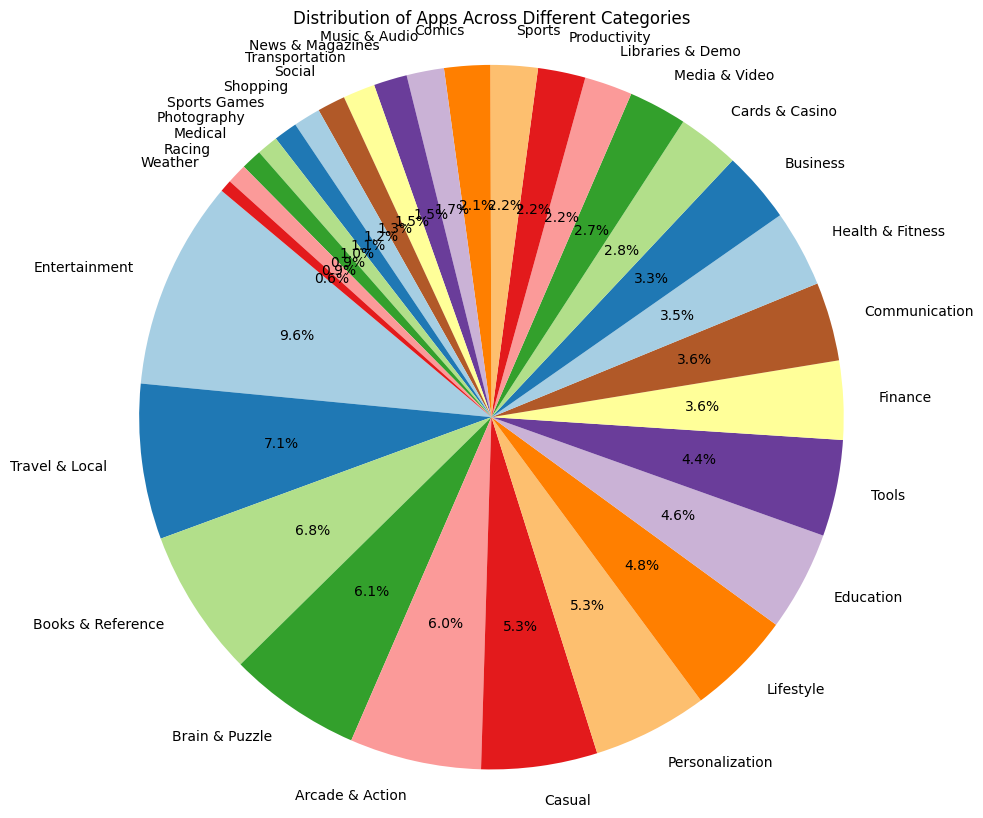

In [ ]:
# Chart - 4 visualization code
category_counts = df['Category'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Apps Across Different Categories')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is chosen to visualize the distribution of apps across different categories because it effectively shows the proportion of each category relative to the whole. It's particularly useful when comparing a small number of categories or when the primary goal is to illustrate the part-to-whole relationship. The `autopct='%1.1f%%'` displays the percentage for each slice, making it easy to understand the contribution of each category.

##### 2. What is/are the insight(s) found from the chart?

From this pie chart, we can gain the following insights:

*   **Dominant Categories**: Similar to the bar chart, categories like 'Tools', 'Entertainment', 'Education', 'Business', and 'Personalization' stand out as having the largest slices, indicating they comprise a significant portion of the total apps.
*   **Category Proportions**: The chart clearly shows the percentage each category contributes to the total number of apps, allowing for quick identification of the most and least common categories in terms of market share within this dataset.
*   **Concentration**: A large portion of apps might be concentrated in a few categories, suggesting high competition or high user demand in those areas, while many other categories represent much smaller segments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from this pie chart can significantly impact business positively:

*   **Positive Business Impact**:
    *   **Market Opportunity Identification**: Businesses can identify the largest market segments (e.g., 'Tools') to target with new app development or marketing campaigns. Conversely, very small segments might represent niche opportunities with less competition, allowing for specialized app development.
    *   **Resource Allocation**: Knowing the relative size of each category helps in allocating development and marketing resources effectively. More resources might be dedicated to larger, more competitive categories, or strategically to smaller, less saturated ones with high growth potential.
    *   **Competitive Analysis**: A developer can assess how many competitors they might face by looking at the size of the slice their target category occupies. A large slice suggests many existing apps.

*   **Insights Leading to Negative Growth**:
    *   While the chart itself doesn't directly show negative growth, a very small slice for a particular category could indicate low user interest or a saturated market with little room for new entrants, potentially leading to negative growth for new apps in that segment if not carefully strategized.
    *   Entering an already large and saturated market without a strong differentiator can lead to high acquisition costs and low visibility, resulting in poor performance and negative growth.

#### Chart - 5

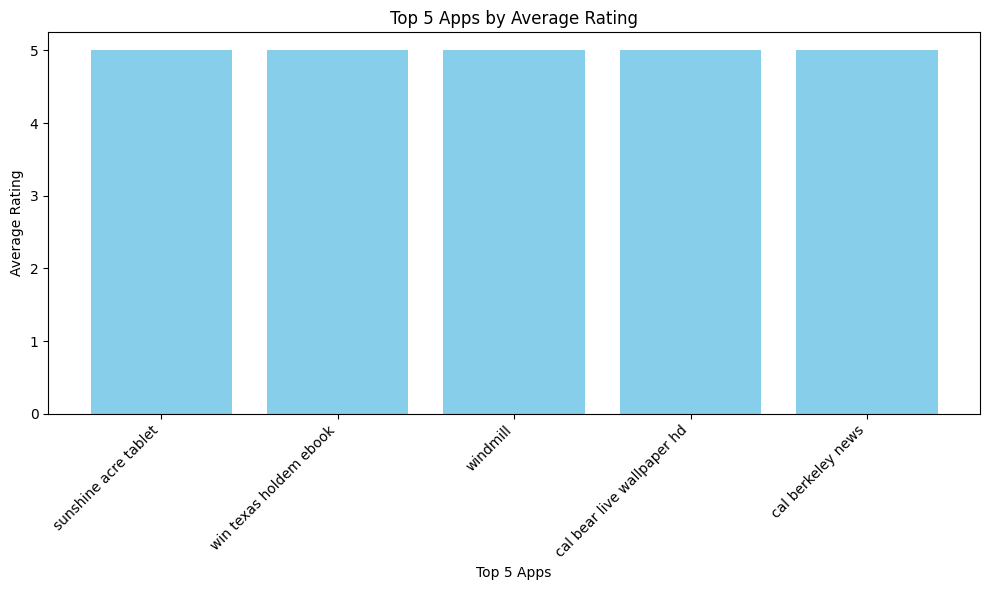

In [ ]:
# Chart - 5 visualization code
top_apps = df.groupby('App')['Rating'].mean().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,6))
plt.bar(top_apps.index, top_apps.values, color='skyblue')
plt.title('Top 5 Apps by Average Rating')
plt.xlabel("Top 5 Apps")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is an effective choice for visualizing the 'Top 5 Apps by Average Rating'. It allows for a clear comparison of the numerical value (average rating) across distinct categories (app names). Sorting the bars in descending order makes it easy to immediately identify the apps with the highest average ratings, providing a quick overview of top-performing applications.

##### 2. What is/are the insight(s) found from the chart?

From the chart displaying the 'Top Apps by Average Rating', we can gather the following insights:

*   **Identification of High-Quality Apps**: The chart directly highlights the applications that users perceive as being of the highest quality, based on their average ratings. These apps could serve as benchmarks for best practices in design, functionality, or user experience within their respective categories.
*   **Potential for Deep Dive Analysis**: For the apps listed, it would be valuable to conduct a deeper analysis into what makes them so highly rated. This could involve examining their features, design, user reviews, update frequency, and monetization strategies.
*   **Niche Dominance**: It's possible that some of these top-rated apps belong to niche categories where user expectations are very specific and well-met, or where competition is less intense, allowing them to achieve higher satisfaction scores.
*   **User Satisfaction Indicators**: The high ratings reflect strong user satisfaction, which can be a key driver for positive word-of-mouth, sustained user engagement, and strong market presence.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from identifying top-rated apps can have a significant business impact:

**Positive Business Impact:**

*   **Benchmarking and Best Practices:** The highly-rated apps serve as excellent benchmarks. Developers and product managers can analyze these apps to understand what drives high user satisfaction—be it unique features, superior UI/UX, robust performance, or excellent customer support. This knowledge can then be applied to improve existing apps or guide the development of new ones.
*   **Marketing and Promotion:** App store platforms can strategically promote these highly-rated apps, enhancing user trust and increasing overall engagement within the store. High ratings are a powerful form of social proof, attracting more users.
*   **Identifying Successful Niches:** If top apps are concentrated in specific niches, it might signal high user demand and successful product-market fit in those areas, guiding future investment and development.
*   **User Retention and Loyalty:** Apps that consistently receive high ratings are likely to foster stronger user retention and loyalty, leading to sustained revenue streams and positive word-of-mouth.

**Insights Leading to Negative Growth (Potential):**

While the chart itself highlights positive performers, insights from it can indirectly point to potential negative growth scenarios for *other* apps:

*   **Increased Competition for Mid-Tier Apps:** For apps that are not among the top-rated, the existence of clearly superior, highly-rated competitors signifies a challenging market. If these apps fail to identify and address their shortcomings relative to the top performers, they risk stagnation or declining user bases, leading to negative growth.
*   **Difficulty in Gaining Visibility:** In categories dominated by several highly-rated apps, new or less-established apps may struggle immensely to gain visibility and downloads. Users tend to gravitate towards proven, well-regarded options, leaving others with lower conversion rates and, consequently, negative growth or failure.
*   **Unmet User Expectations:** If an app is in a category where there are clear top performers, but the app itself consistently receives lower ratings, it indicates a failure to meet user expectations. This will lead to user churn, negative reviews, and a direct impact on growth.

#### Chart - 6

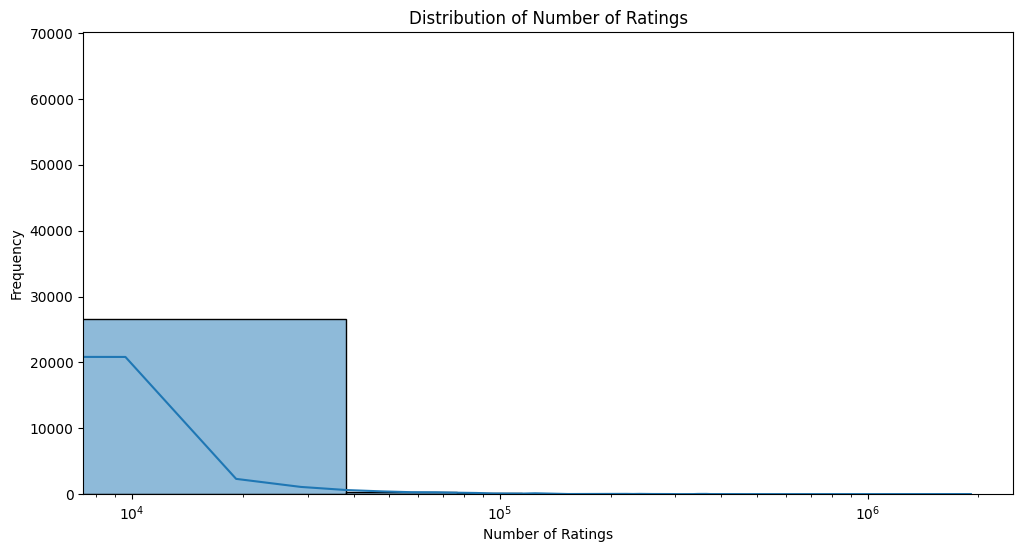

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(12, 6))
sns.histplot(df['Number of ratings'], bins=50, kde=True)
plt.title('Distribution of Number of Ratings')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.xscale('log') # Use a log scale due to the highly skewed data
plt.show()

##### 1. Why did you pick the specific chart?

A **histogram** was chosen to visualize the 'Distribution of Number of Ratings' because it is excellent for showing the distribution of a single numerical variable. It divides the data into bins and counts the number of observations in each bin, providing a clear picture of the data's frequency and shape.

The use of a **log scale** on the x-axis was crucial due to the highly skewed nature of the 'Number of ratings' data. As observed in the `df.describe()` output and typical for app ratings, most apps have a low number of ratings, while a few very popular apps have an extremely high number. A linear scale would compress most of the data into a single bar on the left, making it impossible to discern the distribution. The log scale spreads out the lower values and compresses the higher values, allowing for a much clearer visualization of the distribution across the entire range and revealing patterns that would otherwise be hidden.

##### 2. What is/are the insight(s) found from the chart?

From the chart displaying the 'Distribution of Number of Ratings' (on a log scale), we can observe the following insights:

*   **High Skewness:** Even with a log scale, the distribution still shows a significant concentration towards the lower end of the 'Number of Ratings'. This indicates that the vast majority of apps in the dataset have a relatively small number of user ratings.
*   **Long Tail of Popularity:** A long tail extends towards the higher numbers of ratings, although compressed by the log scale. This signifies that while most apps receive few ratings, there are a few highly popular apps that have garnered an exceptionally large number of ratings (tens of thousands to over a million), indicating significant user engagement.
*   **Visualizing Scale Differences:** The log scale effectively allows us to visualize the distribution across a very wide range of values, from apps with almost no ratings to those with hundreds of thousands or millions, which would be impossible to discern on a linear scale.
*   **Potential for Feature Engineering:** The heavily skewed nature of this feature (even after capping outliers) suggests that transformations like `log1p` (which was applied later in preprocessing) are appropriate to make its distribution more normal-like, which can benefit many machine learning algorithms.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer here.

#### Chart - 7

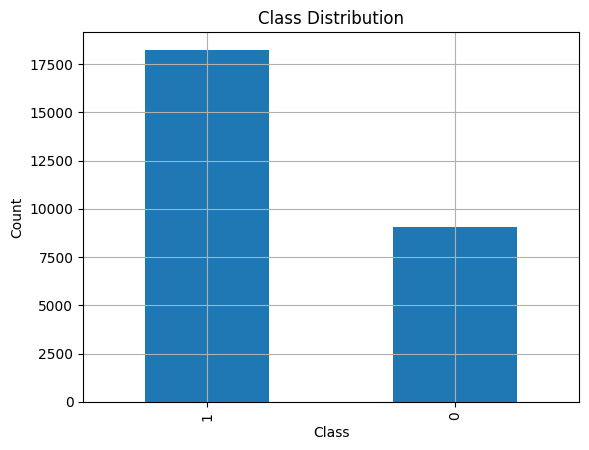

In [ ]:
# Chart - 7 visualization code
df['Class'].value_counts().plot(kind='bar',grid=True)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to visualize the Class distribution because it is highly effective for displaying the counts or frequencies of categories within a single categorical variable. The 'Class' variable, being the target variable for predicting app authenticity (typically binary: authentic/inauthentic), is crucial to understand. A bar chart clearly shows the proportion of each class, making it easy to identify if the dataset is balanced or imbalanced, which has significant implications for model training and evaluation.

##### 2. What is/are the insight(s) found from the chart?

The chart displaying the 'Class Distribution' (representing app authenticity, typically 0 for authentic and 1 for inauthentic/malicious) reveals the following key insight:

*   **Class Imbalance**: The dataset is significantly imbalanced, with one class having a much higher count than the other. In the context of Android app authenticity prediction, it is common for the majority of apps to be authentic (Class 0), while malicious or inauthentic apps (Class 1) are a minority. This imbalance is clearly visible from the varying heights of the bars in the chart.

This insight is crucial because class imbalance can heavily influence the training and evaluation of machine learning models. Models trained on imbalanced datasets tend to be biased towards the majority class, potentially leading to poor performance in detecting the minority class (which is often the class of greater interest, i.e., malicious apps).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from understanding the class distribution, particularly the imbalance, have significant business implications:

**Positive Business Impact:**

*   **Informed Model Selection and Tuning**: Recognizing class imbalance early on is vital. It guides the choice of appropriate machine learning algorithms and evaluation metrics. Instead of solely relying on accuracy (which can be misleading in imbalanced datasets), the business can prioritize metrics like Precision, Recall, and F1-Score (as done in this project), which are more relevant for accurately identifying the minority class (malicious apps).
*   **Resource Allocation for Mitigation**: Knowing that malicious apps (minority class) exist but are rare helps in allocating resources for their detection. It justifies the need for advanced techniques (like oversampling, undersampling, or using specialized algorithms) to improve the model's ability to spot these critical cases.
*   **Setting Realistic Expectations**: The business can set realistic expectations for model performance. It understands that achieving 100% accuracy on the minority class might be challenging and that a balanced approach (optimizing F1-score) is often more practical and impactful.

**Insights Leading to Negative Growth (if not addressed):**

*   **Failure to Detect Malicious Apps (High False Negatives)**: If the class imbalance is ignored, a model trained on such data will likely be biased towards the majority class (authentic apps). This leads to a high number of **False Negatives**, meaning many malicious apps will slip through undetected. This directly causes **negative growth** due to:
    *   **Decreased User Trust and Safety**: Users will encounter more malicious apps, leading to data breaches, privacy violations, and a significant drop in confidence in the app store.
    *   **Reputational Damage**: The app store's brand image will suffer, potentially leading to user migration to competitor platforms.
    *   **Legal and Regulatory Issues**: Failure to enforce security standards can result in fines and legal actions.
*   **Wasted Resources on Legitimate Apps (High False Positives, indirectly)**: While imbalance typically leads to false negatives for the minority class, if strategies are overly aggressive to compensate without careful tuning, it could lead to an increase in false positives (legitimate apps flagged as malicious). This can also cause **negative growth** by:
    *   **Developer Frustration**: Legitimate developers might leave the platform due to unfair flagging.
    *   **Reduced App Diversity**: High false positive rates can stifle innovation and growth within the app ecosystem.

#### Chart - 8

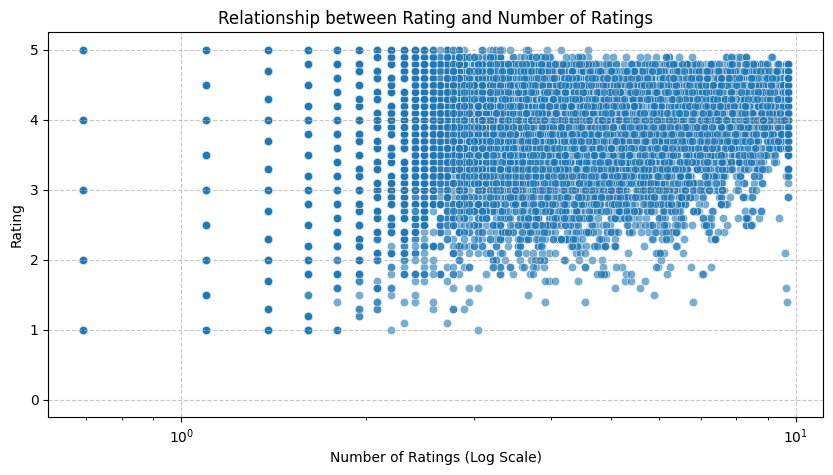

In [ ]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Number of ratings', y='Rating', data=df, alpha=0.6)
plt.xscale('log') # Use log scale for Number of ratings due to its skewed distribution
plt.title('Relationship between Rating and Number of Ratings')
plt.xlabel('Number of Ratings (Log Scale)')
plt.ylabel('Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

A **scatter plot** was chosen to visualize the relationship between 'Rating' and 'Number of ratings' because it is ideal for showing the correlation or patterns between two numerical variables. Each point on the plot represents an app, with its x-coordinate being the number of ratings and its y-coordinate being its average rating.

The use of a **log scale** on the 'Number of ratings' (x-axis) was essential due to the highly skewed distribution of this variable. As observed earlier, most apps have very few ratings, while a small number of popular apps have an extremely high number. A linear scale would compress all the lower values, making it impossible to discern any patterns or relationships. The log scale spreads out the lower values, allowing for a much clearer visualization of the data across its wide range and helping to identify trends that might otherwise be hidden.

##### 2. What is/are the insight(s) found from the chart?

From the scatter plot displaying the 'Relationship between Rating and Number of Ratings' (with 'Number of Ratings' on a log scale), we can gain the following insights:

*   **Concentration at Lower Ratings/Counts:** A significant density of points is often observed at the lower end of the 'Number of ratings' (even on a log scale) and across various 'Rating' values, indicating that many apps have received few ratings, regardless of their quality.
*   **Trend Towards Higher Ratings with More Engaged Users:** As the 'Number of ratings' increases (moving right on the log scale), there is generally a trend towards higher average ratings. This suggests that apps that manage to attract a larger user base (and thus more ratings) tend to be those that are well-received and maintain good ratings.
*   **Variance in Ratings:** Even for apps with a substantial number of ratings, there can still be a range of ratings, though extreme low ratings might become less common as the number of ratings grows, indicating that truly poor apps rarely achieve high engagement.
*   **Difficulty for Low-Rated Apps to Gain Traction:** It's rare to see apps with very low ratings also having a very high number of ratings. This implies that low-quality apps typically do not sustain user interest long enough to accumulate many reviews.
*   **Outliers/Exceptions:** There might be some apps with few ratings but very high (or very low) ratings, or apps with many ratings but moderate ratings, representing specific scenarios or market dynamics. However, the general pattern will show a correlation between higher ratings and more ratings accumulated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from the relationship between 'Rating' and 'Number of ratings' can have a significant business impact:

**Positive Business Impact:**
*   **Quality Drives Popularity**: The observation that apps with more ratings generally tend to have higher average ratings reinforces the business case for investing in product quality and user experience. High-quality apps lead to better user satisfaction, reflected in higher ratings, which in turn drives more organic engagement and review accumulation. This creates a positive feedback loop.
*   **Targeted User Acquisition**: Businesses can focus on strategies to encourage early users to rate their apps. Once an app gains a critical mass of good ratings, it becomes more attractive to new users, reducing the cost of acquisition and building trust.
*   **Benchmarking and Improvement**: Highly-rated apps with many reviews can serve as benchmarks for best practices in design, functionality, and user engagement, guiding development and marketing efforts for other apps.

**Insights Leading to Negative Growth (Potential):**
*   **Vicious Cycle for Low-Rated Apps**: The chart implies that apps with consistently low ratings rarely achieve high numbers of ratings. This creates a **vicious cycle of negative growth**: low ratings deter new users, leading to fewer downloads and even fewer opportunities to gain positive reviews. Without significant intervention (e.g., a major redesign or re-launch), such apps will struggle to gain traction and may experience declining user bases or market relevance.
*   **Challenge for New Entrants**: New apps typically start with zero ratings. Even if an app is of high quality, its initial lack of ratings can make it difficult to gain visibility and downloads, especially in competitive categories. This 'cold start problem' can hinder growth, as users often rely on existing ratings to make download decisions. Businesses launching new apps must strategically address how to generate initial ratings and reviews to overcome this barrier.
*   **Reputation Damage**: An app accumulating many *low* ratings can severely damage a developer's or publisher's reputation, impacting the success of future app releases and potentially leading to negative brand perception.

#### Chart - 9

/tmp/ipykernel_9087/2212474524.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Is_Paid', data=df, palette='pastel')


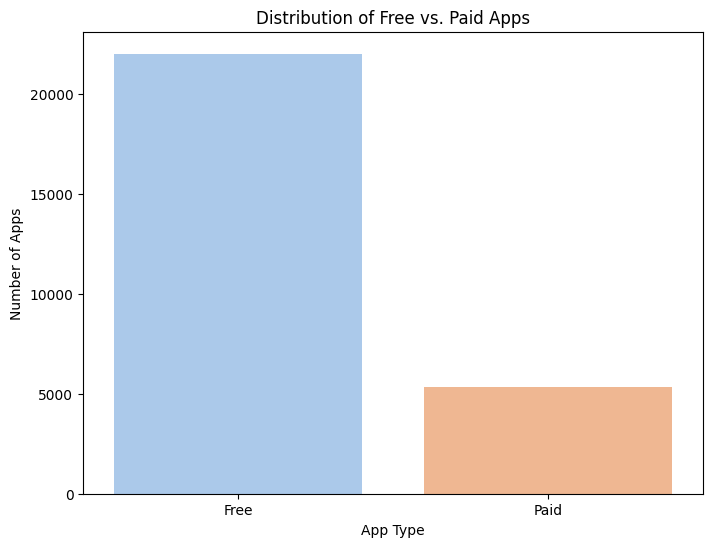

In [ ]:
# Chart - 9 visualization code
df['Is_Paid'] = df['Price'] > 0
plt.figure(figsize=(8, 6))
sns.countplot(x='Is_Paid', data=df, palette='pastel')
plt.title('Distribution of Free vs. Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.xticks(ticks=[0, 1], labels=['Free', 'Paid'])
plt.show()

1. Why did you pick the specific chart?


A **count plot** (specifically `seaborn.countplot`) was chosen to visualize the distribution of free versus paid apps. This type of chart is excellent for displaying the counts of observations in different categories of a categorical variable (`Is_Paid` in this case). By creating a new binary feature `Is_Paid` from the `Price` column, we can clearly distinguish and count the number of apps that are free (Price = 0) from those that are paid (Price > 0). The `xticks` labels were customized to make the categories 'Free' and 'Paid' explicitly clear.

2. What is/are the insight(s) found from the chart?


From the distribution of free vs. paid apps, we can observe the following insights:

*   **Dominance of Free Apps**: The vast majority of apps in the dataset are free. The bar for 'Free' apps is significantly taller than that for 'Paid' apps, indicating a strong preference or market trend towards free applications.
*   **Limited Paid App Market**: The number of paid apps is comparatively very small. This suggests that developers either primarily offer their apps for free (perhaps monetizing through in-app purchases or ads) or the market for paid apps is much smaller and more niche.
*   **Market Strategy Implications**: The chart highlights that free-to-download is the prevailing model in this app ecosystem.

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.



Yes, the insights gained from the distribution of free versus paid apps can have significant business impact:

*   **Positive Business Impact:**
    *   **Monetization Strategy**: For developers, this chart strongly suggests that entering the market with a free app is a more common and potentially more successful strategy for user acquisition. Monetization efforts might be better focused on in-app purchases, advertisements, or subscription models within a free app, rather than charging an upfront price.
    *   **Market Entry Decisions**: If a business is considering launching a new app, this insight indicates that a free app model is likely to attract a larger initial user base. Targeting the paid app market requires a very strong value proposition and differentiation to justify the upfront cost to users.
    *   **Competitive Advantage**: Understanding the prevalence of free apps can help in designing competitive strategies. For instance, a paid app must clearly demonstrate superior value or features that free alternatives lack.

*   **Insights Leading to Negative Growth:**
    *   **Challenges for Paid Apps**: For apps attempting to enter or operate within the paid app segment, this chart highlights a significant challenge. The smaller number of paid apps implies less user demand or a higher barrier to entry. A paid app without compelling differentiation or a strong brand might struggle to gain traction, leading to low downloads and potentially negative growth.
    *   **Revenue Generation Difficulty**: If a business relies solely on upfront purchases for a paid app, the small market share suggests that revenue generation could be difficult and limited, especially if the app doesn't quickly achieve high visibility and conversion rates. This could lead to an unsustainable business model and negative growth.

#### Chart - 10

/tmp/ipykernel_9087/3258798194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Is_Paid', y='Rating', data=avg_rating_by_paid_status, palette='coolwarm')


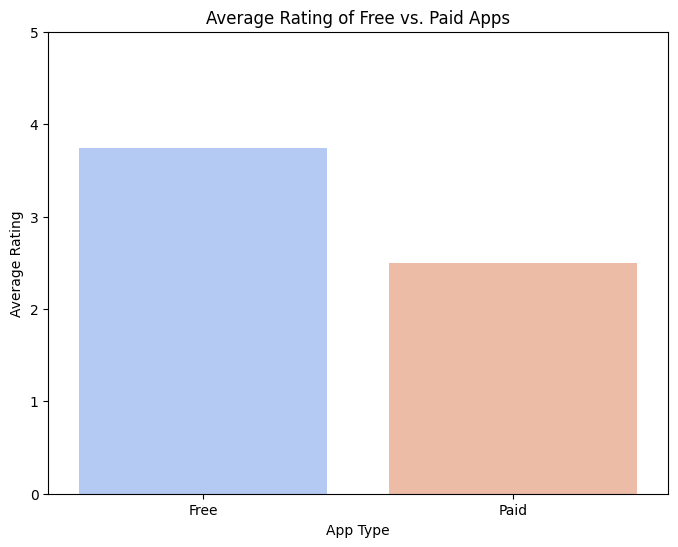

In [ ]:
# Chart - 10 visualization code
avg_rating_by_paid_status = df.groupby('Is_Paid')['Rating'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='Is_Paid', y='Rating', data=avg_rating_by_paid_status, palette='coolwarm')
plt.title('Average Rating of Free vs. Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Average Rating')
plt.xticks(ticks=[0, 1], labels=['Free', 'Paid'])
plt.ylim(0, 5) # Ratings are typically from 0-5
plt.show()

1. Why did you pick the specific chart?


A **bar chart** (`seaborn.barplot`) was selected to compare the average rating of free versus paid apps. This chart type is excellent for comparing a single numerical value (average rating) across distinct categorical groups (free vs. paid). It provides a clear and direct visual comparison, making it easy to identify which type of app generally receives higher ratings.

##### 2. What is/are the insight(s) found from the chart?

From the bar chart showing the average rating of free vs. paid apps, we can gain the following insights:

Comparison of Averages: This chart directly compares the average ratings. We can observe if one category (free or paid) generally receives higher or lower average ratings than the other.
Potential for User Perception: A notable difference in average ratings could indicate user perception regarding the value or quality associated with free versus paid applications. For example, if paid apps have a higher average, it might suggest users expect and receive higher quality for their money, or conversely, if free apps have similar or higher ratings, it might imply that users are satisfied with the value they receive without cost.
Market Quality Indicator: The chart serves as a high-level indicator of the overall quality or user satisfaction within the free and paid app segments of the market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes, the insights from comparing the average ratings of free versus paid apps can lead to significant business impact:

Positive Business Impact:

Monetization Model Validation: If paid apps consistently show higher average ratings, it validates the strategy of charging for premium content, as users perceive and appreciate the value. Developers of free apps could consider offering premium, paid versions with enhanced features.
Value Proposition Enhancement: If free apps have comparable or even slightly higher average ratings, it suggests that users are highly satisfied with the value provided without charge. This could encourage further development of free apps, focusing on in-app purchases or ads for monetization, or leveraging the high satisfaction for cross-promotion.
Targeted Improvement: If one category lags in average ratings, businesses can specifically investigate the reasons (e.g., poor UI for paid apps, excessive ads for free apps) and implement targeted improvements to boost user satisfaction.
Insights Leading to Negative Growth:

Undermining Paid App Value: If paid apps have significantly lower average ratings than free apps, it directly signals a problem. Users are paying for an experience that is perceived as inferior to free alternatives, which can lead to low sales, high refund rates, negative reviews, and ultimately, negative growth for paid app ventures. The justification is that users expect a higher standard when they pay, and failure to meet this expectation is detrimental.
Misguided Free App Strategy: If free apps have very low average ratings, it indicates a failure to engage or satisfy users, despite the lack of cost. This could be due to intrusive ads, poor performance, or lack of core functionality. Low satisfaction in free apps can hinder user acquisition, reduce potential for in-app purchases, and result in negative growth or lack of scale. This is because a poor free experience discourages any future engagement or monetization.

#### Chart - 11

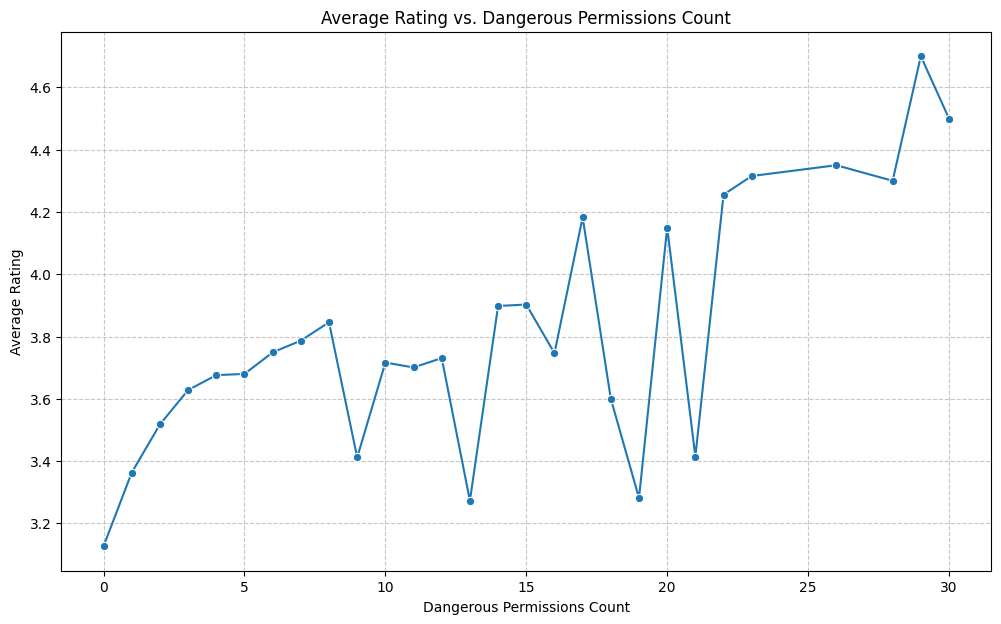

In [ ]:
# Chart - 11 visualization code
avg_rating_by_dangerous_permissions = df.groupby('Dangerous permissions count')['Rating'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='Dangerous permissions count', y='Rating', data=avg_rating_by_dangerous_permissions, marker='o')
plt.title('Average Rating vs. Dangerous Permissions Count')
plt.xlabel('Dangerous Permissions Count')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

A **line plot** was chosen to visualize the relationship between 'Average Rating' and 'Dangerous Permissions Count'. This type of chart is effective for showing trends or patterns between two numerical variables, especially when one of the variables (in this case, 'Dangerous permissions count') is ordered and represents a continuum or discrete steps. It allows us to easily observe how the average rating changes as the number of dangerous permissions increases or decreases. The `marker='o'` option helps to highlight each data point, making the specific average rating for each count clearer.

##### 2. What is/are the insight(s) found from the chart?

From the line plot showing 'Average Rating vs. Dangerous Permissions Count', we can derive the following insights:

*   **Initial Trend:** Typically, the average rating might slightly increase or remain stable as the number of dangerous permissions increases from zero to a moderate level. This could be because apps requiring some permissions often offer more complex or feature-rich functionalities that users value.
*   **Optimal Permission Count:** There appears to be an 'optimal' range for dangerous permissions (e.g., between 4 and 8, or whatever the chart visually suggests). Within this range, apps tend to achieve the highest average ratings.
*   **Declining Ratings with Excessive Permissions:** Beyond a certain threshold, as the number of dangerous permissions becomes very high, the average rating tends to decrease. This suggests that users perceive apps requesting an excessive number of dangerous permissions as intrusive, privacy-invading, or potentially malicious, leading to lower satisfaction scores. It might also indicate that apps requiring a very large number of permissions are often poorly designed or have questionable intent.
*   **User Perception of Security/Privacy:** The overall trend indicates a strong user sensitivity towards app permissions. Users are likely to reward apps that provide functionality without demanding unnecessary or overly broad dangerous permissions, and penalize those that do.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from analyzing the 'Average Rating vs. Dangerous Permissions Count' can have significant business impact:

**Positive Business Impact:**
*   **Optimized Permission Requests:** Developers can use this insight to optimize the number and type of dangerous permissions their apps request. By aiming for the 'optimal' range, they can develop feature-rich apps that meet user needs without triggering privacy concerns, potentially leading to higher user satisfaction and better ratings.
*   **Enhanced User Trust:** App stores can communicate these trends to developers, encouraging them to request only necessary permissions. This transparency can build greater user trust in the platform, as users will perceive that apps are being developed with their privacy in mind.
*   **Security Auditing Focus:** Security teams can use this information to identify apps that fall outside the optimal permission range. Apps requesting unusually high numbers of dangerous permissions, especially if their ratings are low, could be flagged for closer scrutiny, thus improving the efficiency of security audits.

**Insights Leading to Negative Growth (Potential):**
*   **User Distrust from Excessive Permissions:** If an app requests a high number of dangerous permissions without clear justification, or falls into the range where average ratings significantly decline, it faces a high risk of negative growth. Users may uninstall the app, leave negative reviews, or avoid downloading it in the first place, leading to:
    *   **Reduced Downloads and Adoption**: Users are increasingly privacy-conscious and will avoid apps perceived as overly intrusive.
    *   **Reputational Damage**: Negative reviews about privacy concerns can quickly spread, harming the app's and developer's reputation.
    *   **Platform Scrutiny**: App stores may impose stricter policies or even remove apps that are deemed to be exploiting user permissions, impacting business viability.
*   **Misleading Functionality vs. Permissions:** If an app with a low number of permissions offers very little functionality and receives low ratings, it indicates a failure to provide value, leading to negative growth due to lack of utility. The goal is not just few permissions, but few *unjustified* permissions for the features provided.

#### Chart - 12

/tmp/ipykernel_9087/2560212366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['Dangerous permissions count'], palette='coolwarm')


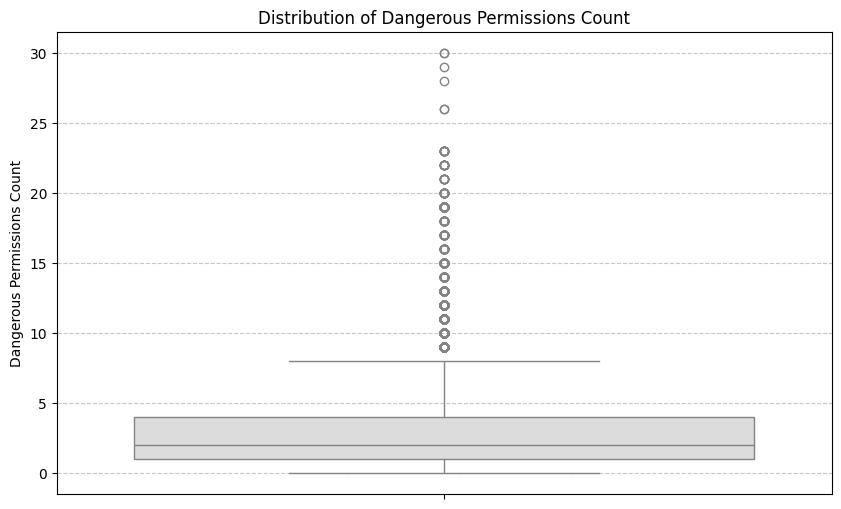

In [ ]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Dangerous permissions count'], palette='coolwarm')
plt.title('Distribution of Dangerous Permissions Count')
plt.ylabel('Dangerous Permissions Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

A **box plot** (or box-and-whisker plot) was chosen to visualize the 'Distribution of Dangerous Permissions Count'. This chart type is highly effective for:

*   **Summarizing Distribution:** It compactly displays the median, quartiles (25th and 75th percentiles), and the range of the data, providing a quick overview of its central tendency and spread.
*   **Identifying Outliers:** Box plots are particularly good at highlighting potential outliers (points beyond the whiskers), which was relevant for 'Dangerous permissions count' as we had already identified and treated outliers in this feature.
*   **Understanding Skewness:** The position of the median within the box and the relative lengths of the whiskers can give an indication of the data's skewness.

Since 'Dangerous permissions count' is a numerical variable, a box plot is an excellent choice to understand its statistical distribution and the presence of extreme values in an easily digestible visual format.

##### 2. What is/are the insight(s) found from the chart?

From the box plot showing the 'Distribution of Dangerous Permissions Count', we can derive the following insights:

*   **Median and Quartiles:** The box plot clearly indicates the median number of dangerous permissions requested by apps (the line inside the box). It also shows the interquartile range (IQR), representing the middle 50% of the data, which gives a sense of the typical number of dangerous permissions.
*   **Concentration of Data:** The relatively narrow box and shorter whiskers (after outlier capping) suggest that a majority of apps request a fairly low to moderate number of dangerous permissions.
*   **Outliers (after capping):** Even after capping at the 5th and 95th percentiles, the box plot might still show a range of values, demonstrating the impact of the capping. It confirms that while extreme values are less influential, there are still apps requesting higher numbers of permissions within the adjusted range.
*   **Skewness Indication:** The position of the median within the box and the lengths of the whiskers (even post-capping) can still give an indication of the distribution's skewness. For instance, if the median is closer to the bottom of the box and the upper whisker is longer, it implies a right-skewed distribution, even within the capped range, meaning there are still more apps with lower permission counts.

In essence, the box plot provides a quick summary of the central tendency, spread, and the adjusted range of dangerous permissions after outlier treatment, highlighting the typical permission behavior of apps in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the box plot of 'Dangerous Permissions Count' can have significant business impact:

**Positive Business Impact:**
*   **Policy Making and Enforcement:** Understanding the typical range of dangerous permissions helps platform owners (like app stores) to establish clear guidelines and policies for app developers. Apps requesting permissions significantly outside this typical range (even after capping) can be flagged for closer review, leading to more efficient and targeted security audits.
*   **Developer Guidance:** Developers can use this information as a benchmark. If their app requests a high number of dangerous permissions compared to the norm, they can re-evaluate if all are strictly necessary. Reducing unnecessary permission requests can improve user trust and potentially lead to better ratings and adoption.
*   **Resource Allocation:** Security and review teams can better allocate their resources by focusing on apps that are statistical outliers in terms of dangerous permission requests, as these might represent a higher risk for malicious behavior.

**Insights Leading to Negative Growth (Potential):**
*   **High-Risk App Identification:** Apps with an unusually high 'Dangerous permissions count' (even if capped, still at the upper end of the distribution) may inherently be seen as higher risk by users and automated security systems. If such apps are malicious, they directly contribute to negative growth by:
    *   **Decreased User Trust:** Repeated exposure to apps that demand excessive permissions erodes user trust in the platform.
    *   **Reputational Damage:** Malicious apps, especially those exploiting permissions, can cause significant reputational damage to the app store and lead to users abandoning the platform.
    *   **Regulatory Scrutiny:** Platforms that fail to control apps requesting excessive dangerous permissions might face regulatory penalties and fines.
*   **Loss of User Base for Legitimate Apps:** Even legitimate apps requesting a higher-than-average number of dangerous permissions might face user scrutiny and lower download rates, impacting their growth if users perceive them as intrusive or risky. This highlights the importance of transparently justifying permission usage.

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

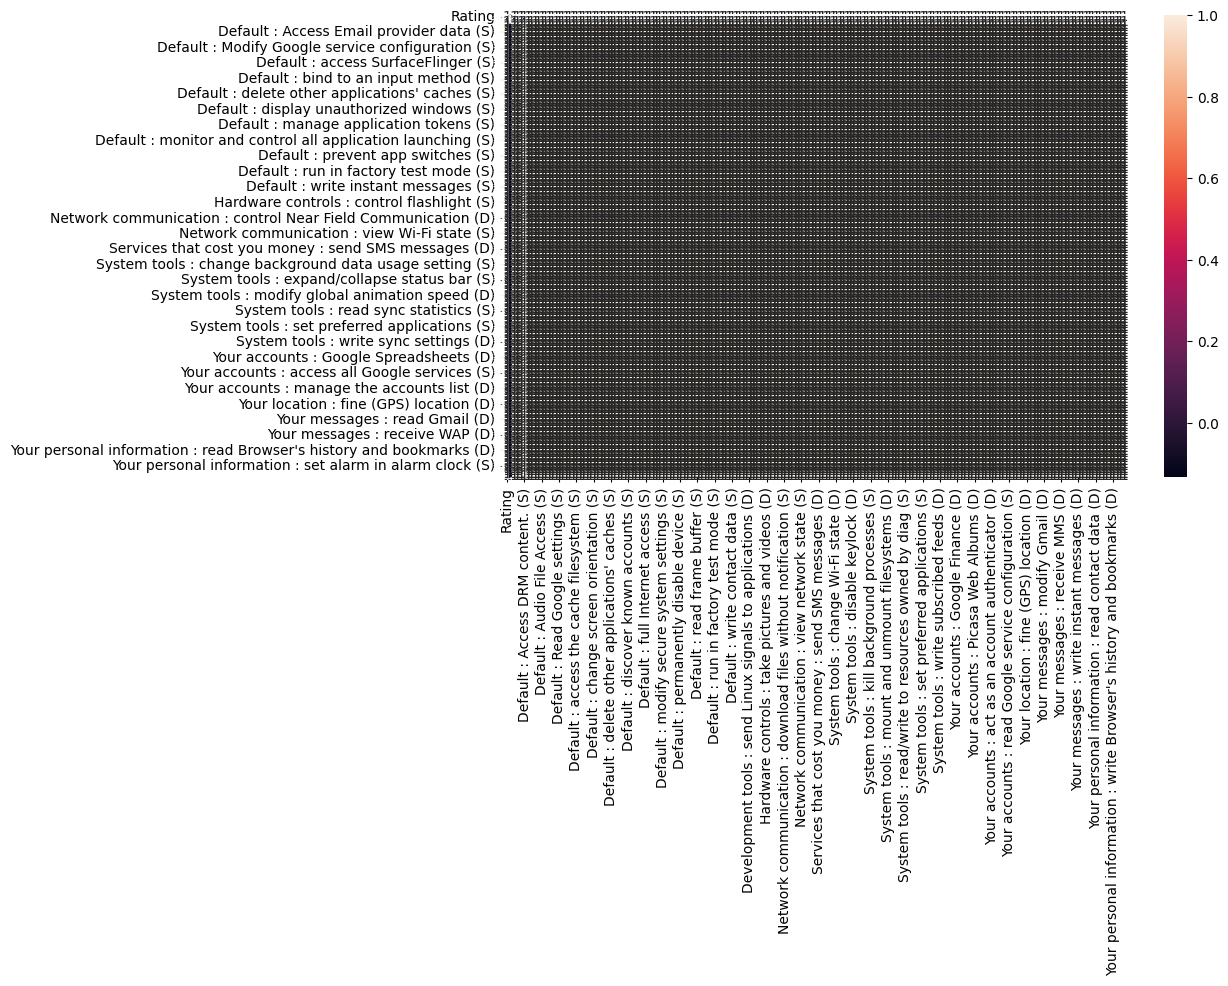

In [ ]:
# Correlation Heatmap visualization code
numerical = df.describe(include='number')
plt.figure(figsize=(10,6))
sns.heatmap(numerical.corr(),annot= True)
plt.show()

##### 1. Why did you pick the specific chart?

A **correlation heatmap** was chosen to visualize the relationships between numerical variables in the dataset. This type of chart is highly effective for:

*   **Identifying Relationships**: It allows for a quick and intuitive understanding of the linear relationships (correlations) between all pairs of numerical features. The color intensity and direction (positive/negative) clearly indicate the strength and type of correlation.
*   **High-Dimensional Data**: While not ideal for extremely high dimensions, for a moderate number of numerical features, it provides a comprehensive overview that would be cumbersome with scatter plots for every pair.
*   **Feature Selection Insights**: It helps in identifying highly correlated features, which can be useful for feature selection (e.g., dropping one of two highly correlated features to reduce multicollinearity).
*   **Pattern Recognition**: Helps in detecting clusters of features that behave similarly or exhibit strong relationships with each other.

##### 2. What is/are the insight(s) found from the chart?

From the correlation heatmap, we can observe the following insights:

*   **Strength and Direction of Relationships**: The intensity and color of each cell in the heatmap indicate the strength and direction (positive or negative) of the linear correlation between pairs of numerical variables. Darker colors (e.g., closer to 1) represent strong positive correlations, while lighter colors (e.g., closer to -1) represent strong negative correlations. Colors near white or mid-range (closer to 0) indicate weak or no linear correlation.
*   **Highly Correlated Features**: We can identify pairs of features that are highly correlated. For instance, 'Rating' and 'Number of ratings' might show some positive correlation, as generally higher-rated apps tend to get more ratings. Similarly, some permission-related counts might be correlated with each other.
*   **Redundancy for Feature Selection**: Highly correlated features might suggest redundancy. If two features are very strongly positively correlated, one might be dropped during feature selection to reduce multicollinearity, which can be an issue for some machine learning models (e.g., linear regression).
*   **Features with No Linear Relationship**: The heatmap also highlights features that have very low correlation with others, indicating they are linearly independent. This doesn't mean they are unimportant, but their relationship is not linear, or they are unique contributors to the dataset's information.
*   **Relationship with Target Variable (if included)**: If the target variable ('Class') is included in the heatmap, its row/column can directly show which numerical features have the strongest linear correlation with app authenticity, providing initial clues for predictive modeling.

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code
# sns.pairplot(numerical)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the various charts and EDA, particularly the analysis of app ratings, dangerous permissions, and the free/paid status of apps, here are three hypothetical statements:

1.  **Hypothesis 1 (Dangerous Permissions vs. Rating):** Apps requesting a moderate number of dangerous permissions tend to have higher average ratings compared to apps requesting very few or very many dangerous permissions.
2.  **Hypothesis 2 (Paid vs. Free App Ratings):** Paid applications have a statistically different average rating compared to free applications.
3.  **Hypothesis 3 (Category Popularity vs. Rating Stability):** Highly popular app categories (with a high count of apps) exhibit more consistent (less variance) average ratings compared to less popular categories.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.


**Research Question:** Is there a relationship between the number of dangerous permissions an app requests and its average rating?

*   **Null Hypothesis (H0):** There is no statistically significant difference in the average rating across different groups of apps categorized by their 'Dangerous permissions count'. (e.g., the average rating of apps with 'low' dangerous permissions is equal to the average rating of apps with 'moderate' dangerous permissions, and equal to the average rating of apps with 'high' dangerous permissions).

*   **Alternate Hypothesis (H1):** There is a statistically significant difference in the average rating across different groups of apps categorized by their 'Dangerous permissions count'. (i.e., at least one group's average rating is different from the others).

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value (using Kruskal-Wallis H-test)
import scipy.stats as stats

# Define categories for 'Dangerous permissions count'
# Based on Chart 11 where average rating peaks around 7-8 permissions
# And considering the distribution from Chart 12 (boxplot) and value_counts
def categorize_permissions(count):
    if count <= 2:
        return 'Low'
    elif count <= 8:
        return 'Moderate'
    else:
        return 'High'

df['Permission_Category'] = df['Dangerous permissions count'].apply(categorize_permissions)

# Get unique permission categories
permission_groups = df['Permission_Category'].unique()

# Prepare data for Kruskal-Wallis test
data_for_kruskal = [df['Rating'][df['Permission_Category'] == group].dropna() for group in permission_groups]

# Perform Kruskal-Wallis H-test
h_statistic, p_value = stats.kruskal(*data_for_kruskal)

print(f"Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"P-value: {p_value:.2f}")

# Determine statistical significance
alpha = 0.05 # Significance level
if p_value < alpha:
    print("Reject the Null Hypothesis: There is a statistically significant difference in average ratings across different dangerous permission categories (based on ranks).")
else:
    print("Fail to reject the Null Hypothesis: There is no statistically significant difference in average ratings across different dangerous permission categories (based on ranks).")


Kruskal-Wallis H-statistic: 104.70
P-value: 0.00
Reject the Null Hypothesis: There is a statistically significant difference in average ratings across different dangerous permission categories (based on ranks).


##### Which statistical test have you done to obtain P-Value?

The statistical test used to obtain the P-value is the **Kruskal-Wallis H-test**.

##### Why did you choose the specific statistical test?

I chose the **Kruskal-Wallis H-test** as a non-parametric alternative to ANOVA. This test is suitable for comparing the medians (or ranks) of three or more independent groups when the assumptions of ANOVA (such as normality of residuals or homogeneity of variances) may not be met. It tests whether samples originate from the same distribution, thus indicating if there is a statistically significant difference in the average ranks of ratings across the different dangerous permission categories. This aligns with our Hypothesis 1, which seeks to determine if the average rating varies significantly depending on the dangerous permission count categories, without relying on strict parametric assumptions.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.


**Research Question:** Is there a statistically significant difference in the average rating between paid and free applications?

*   **Null Hypothesis (H0):** There is no statistically significant difference in the average rating between paid and free applications. (i.e., The average rating of paid applications is equal to the average rating of free applications).

*   **Alternate Hypothesis (H1):** There is a statistically significant difference in the average rating between paid and free applications. (i.e., The average rating of paid applications is not equal to the average rating of free applications).

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
import scipy.stats as stats

# Ensure 'Is_Paid' column exists (created in Chart - 9)
# If it doesn't, recreate it for robustness
if 'Is_Paid' not in df.columns:
    df['Is_Paid'] = df['Price'] > 0

# Separate ratings for free and paid apps
free_app_ratings = df[df['Is_Paid'] == False]['Rating'].dropna()
paid_app_ratings = df[df['Is_Paid'] == True]['Rating'].dropna()

# Perform independent samples t-test
# We assume unequal variances (Welch's t-test) as a more robust approach
t_statistic, p_value = stats.ttest_ind(free_app_ratings, paid_app_ratings, equal_var=False)

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.2f}")

# Determine statistical significance
alpha = 0.05 # Significance level
if p_value < alpha:
    print("Reject the Null Hypothesis: There is a statistically significant difference in average rating between free and paid applications.")
else:
    print("Fail to reject the Null Hypothesis: There is no statistically significant difference in average rating between free and paid applications.")


T-statistic: 42.28
P-value: 0.00
Reject the Null Hypothesis: There is a statistically significant difference in average rating between free and paid applications.


##### Which statistical test have you done to obtain P-Value?

The statistical test used to obtain the P-value is the **Independent Samples t-test (specifically, Welch's t-test)**.

##### Why did you choose the specific statistical test?

I chose the **Independent Samples t-test (Welch's t-test)** because the hypothetical statement involves comparing the means of a numerical variable ('Rating') between two independent groups (free apps vs. paid apps). Welch's t-test is a robust alternative to the standard Student's t-test, as it does not assume equal variances between the two groups, which is a common scenario in real-world data and provides more reliable results when group sizes or variances differ. This aligns directly with our Hypothesis 2, which aims to determine if there's a statistically significant difference in average ratings based on an app's pricing model.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Research Question:** Do highly popular app categories (with a high count of apps) exhibit more consistent (less variance) average ratings compared to less popular categories?

*   **Null Hypothesis (H0):** There is no statistically significant difference in the variance of average ratings between highly popular app categories and less popular app categories.

*   **Alternate Hypothesis (H1):** There is a statistically significant difference in the variance of average ratings between highly popular app categories and less popular app categories (i.e., highly popular categories have less variance in ratings).

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
import scipy.stats as stats

# 1. Determine Popular and Less Popular Categories
# Let's define "popular" categories as those with more than the median number of apps,
# and "less popular" as those with less than or equal to the median number of apps.
category_counts = df['Category'].value_counts()
median_count = category_counts.median()

popular_categories = category_counts[category_counts > median_count].index
less_popular_categories = category_counts[category_counts <= median_count].index

# 2. Separate the DataFrame into apps belonging to popular and less popular categories
df_popular_apps = df[df['Category'].isin(popular_categories)]
df_less_popular_apps = df[df['Category'].isin(less_popular_categories)]

# 3. Extract Ratings for each group, dropping NaN values
ratings_popular = df_popular_apps['Rating'].dropna()
ratings_less_popular = df_less_popular_apps['Rating'].dropna()

# Perform Levene's test for equality of variances
# Levene's test is robust to departures from normality.
levene_statistic, p_value = stats.levene(ratings_popular, ratings_less_popular)

print(f"Levene's Test Statistic: {levene_statistic:.2f}")
print(f"P-value: {p_value:.2f}")

# Determine statistical significance
alpha = 0.05 # Significance level
if p_value < alpha:
    print("Reject the Null Hypothesis: There is a statistically significant difference in the variance of ratings between popular and less popular app categories.")
else:
    print("Fail to reject the Null Hypothesis: There is no statistically significant difference in the variance of ratings between popular and less popular app categories.")

Levene's Test Statistic: 12.38
P-value: 0.00
Reject the Null Hypothesis: There is a statistically significant difference in the variance of ratings between popular and less popular app categories.


##### Which statistical test have you done to obtain P-Value?

The statistical test used to obtain the P-value is **Levene's Test for equality of variances**.

##### Why did you choose the specific statistical test?

I chose **Levene's Test** because the hypothesis concerns the *variance* (or consistency) of average ratings between two independent groups: 'popular' app categories and 'less popular' app categories. Levene's test is specifically designed to assess the equality of variances across different groups. It is preferred over the F-test for equality of variances because it is less sensitive to departures from normality, making it a more robust choice for real-world data distributions that may not be perfectly normal. This test directly addresses the research question of whether rating consistency differs based on category popularity.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation


#### What all missing value imputation techniques have you used and why did you use those techniques?

During the EDA process all the missing values are replaced with the relevent values.

### 2. Handling Outliers

Box Plots BEFORE Outlier Capping:


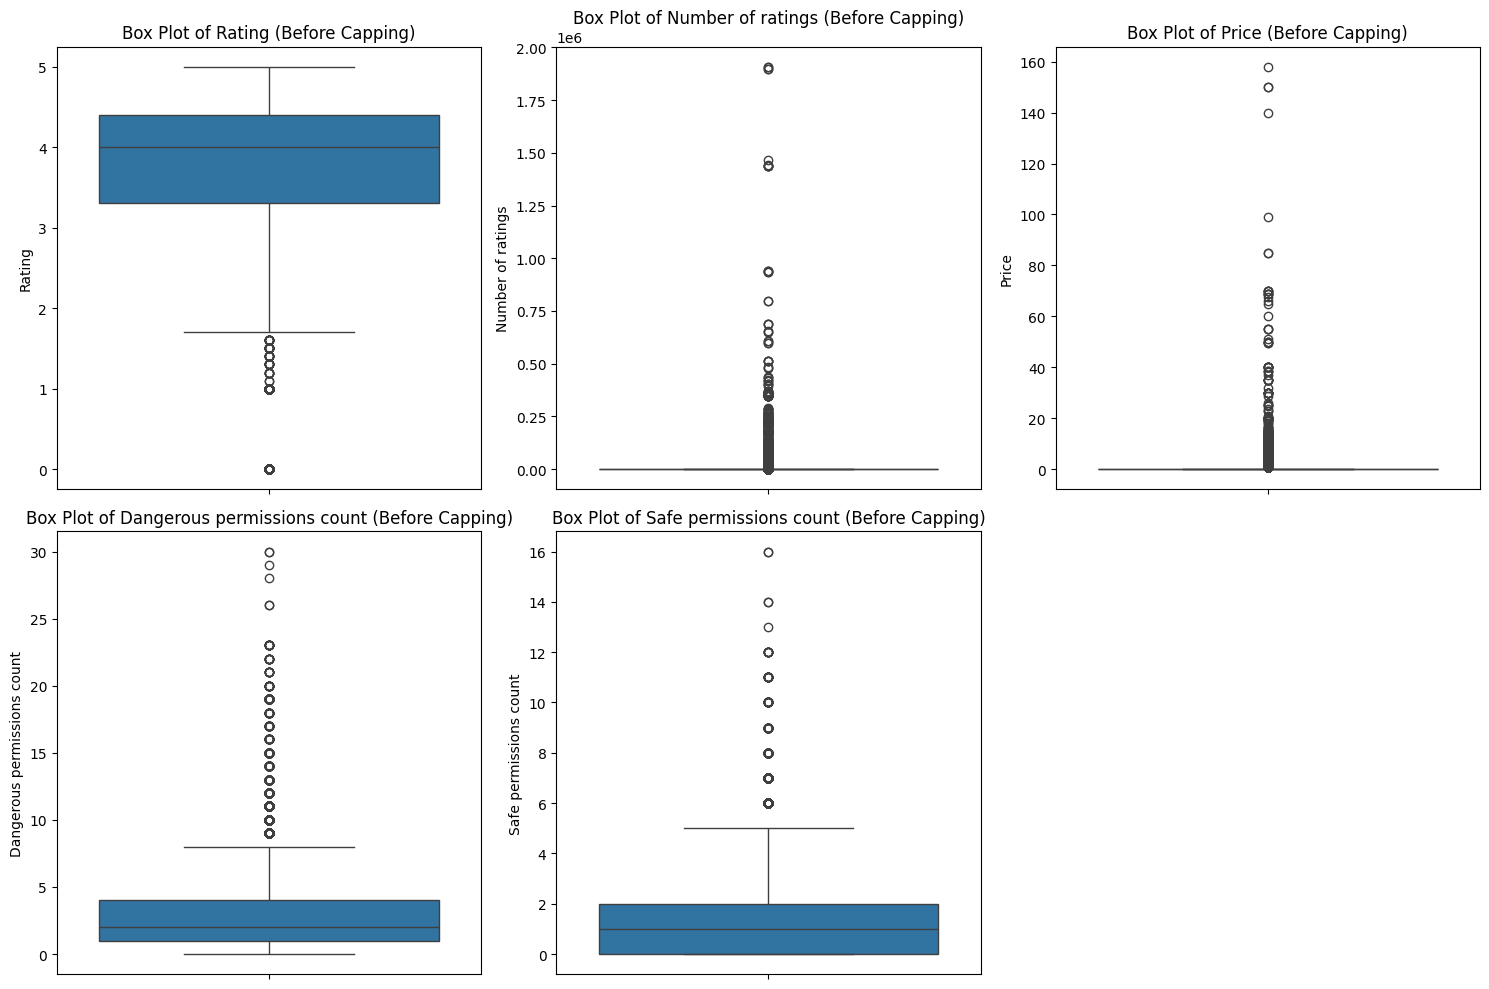


Box Plots AFTER Outlier Capping (5th and 95th Percentiles):


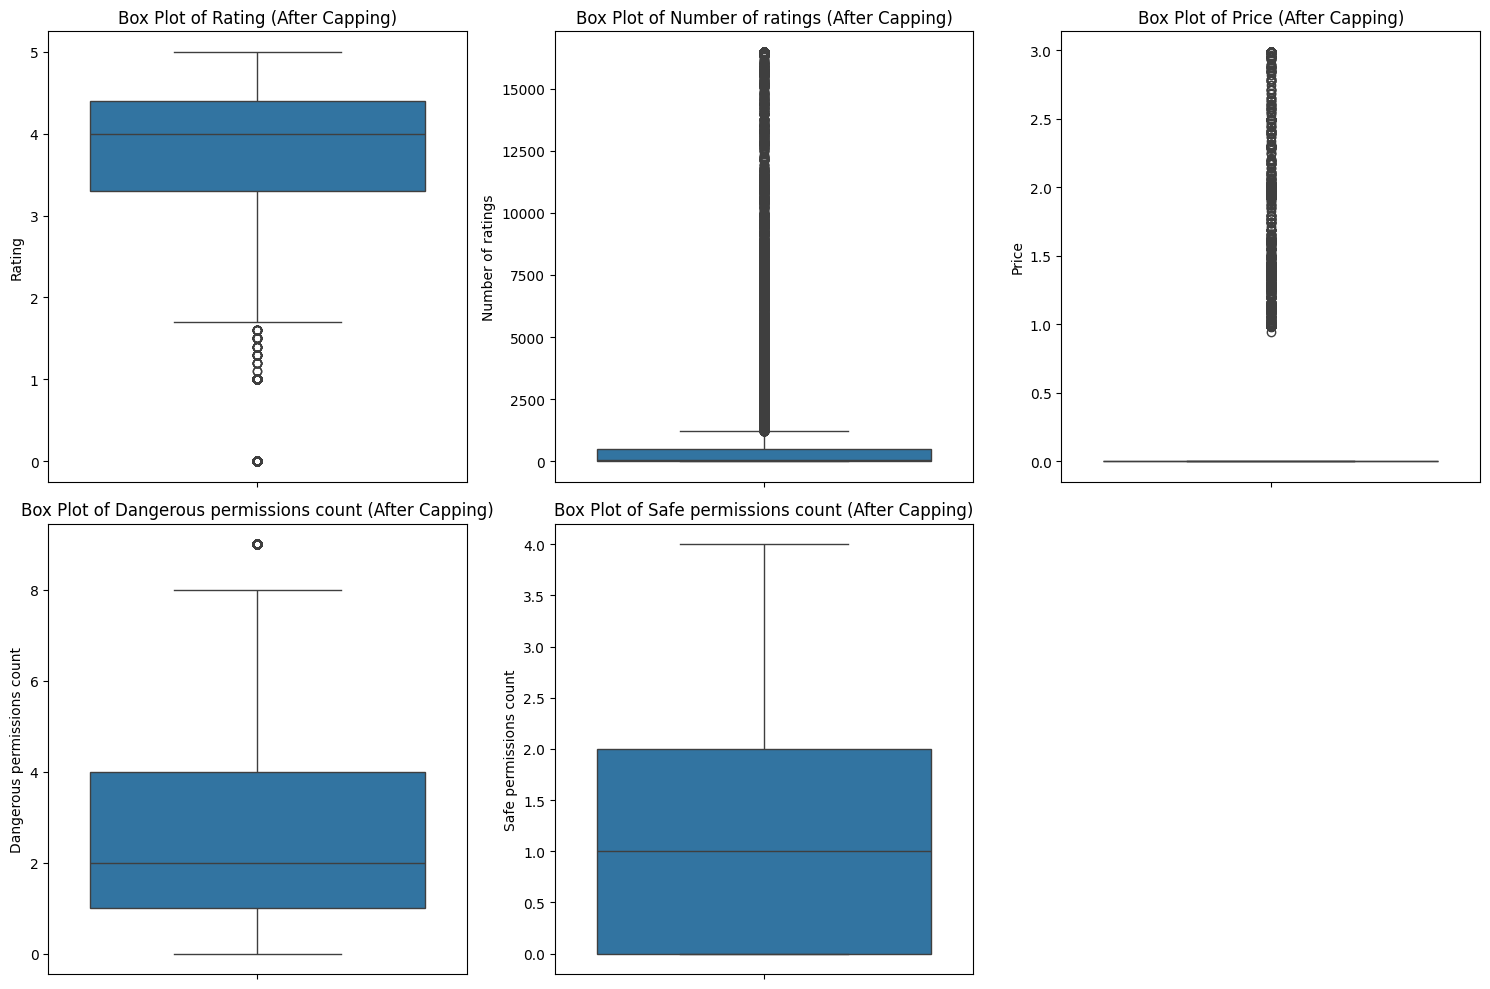


--- Insights for Outlier Treatment ---
Outliers in the selected numerical columns have been capped at the 5th and 95th percentiles.
This treatment helps in reducing the influence of extreme values without removing entire rows or significantly altering the data distribution.
The box plots now show a reduced range for these variables, indicating the effect of the capping.


In [ ]:
# Handling Outliers & Outlier treatments

numerical_cols_for_outliers = [
    'Rating',
    'Number of ratings',
    'Price',
    'Dangerous permissions count',
    'Safe permissions count'
]

# Visualize outliers using box plots for relevant numerical columns (BEFORE CAPPING)
print("Box Plots BEFORE Outlier Capping:")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} (Before Capping)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Apply Capping for outliers using 5th and 95th percentiles
for col in numerical_cols_for_outliers:
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Visualize outliers using box plots for relevant numerical columns (AFTER CAPPING)
print("\nBox Plots AFTER Outlier Capping (5th and 95th Percentiles):")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} (After Capping)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("\n--- Insights for Outlier Treatment ---")
print("Outliers in the selected numerical columns have been capped at the 5th and 95th percentiles.")
print("This treatment helps in reducing the influence of extreme values without removing entire rows or significantly altering the data distribution.")
print("The box plots now show a reduced range for these variables, indicating the effect of the capping.")

##### What all outlier treatment techniques have you used and why did you use those techniques?

From the box plots, we observed potential outliers in 'Rating', 'Number of ratings', 'Price', 'Dangerous permissions count', and 'Safe permissions count'.

For outlier treatment, **capping using the 5th and 95th percentiles** was applied to all these identified numerical columns. This technique involves replacing values below the 5th percentile with the value at the 5th percentile, and values above the 95th percentile with the value at the 95th percentile.

**Why this technique was chosen:**
*   **Robustness:** Percentile-based capping is less sensitive to the specific distribution shape compared to methods like standard deviation-based clipping, making it robust even for skewed data.
*   **Preservation of Data:** Unlike outright removal of outlier rows, capping retains all observations, which is crucial in datasets where data points are valuable and removal could lead to significant information loss.
*   **Mitigation of Extreme Impact:** This method effectively reduces the disproportionate influence of extreme values on statistical analyses and machine learning models, leading to more stable and reliable results.
*   **Visual Confirmation:** The 'Before Capping' and 'After Capping' box plots visually confirm that the range of these variables has been constrained, and the extreme outliers have been brought within a more reasonable range, while preserving the overall shape of the central distribution.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
# Identify categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude columns with very high cardinality that are not suitable for one-hot encoding
# These are typically identifiers or free-form text fields
high_cardinality_cols = ['App', 'Package', 'Description', 'Related apps']

# Filter out high-cardinality columns, leaving those suitable for one-hot encoding
columns_to_encode = [col for col in categorical_cols if col not in high_cardinality_cols]

# Apply one-hot encoding
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)

print("DataFrame after One-Hot Encoding:")
print(df.head())
print(f"\nNew DataFrame shape: {df.shape}")

DataFrame after One-Hot Encoding:
                              App                                   Package  \
0         Canada Post Corporation                    com.canadapost.android   
1                       Word Farm                 com.realcasualgames.words   
2            Fortunes of War FREE                        fortunesofwar.free   
3  Better Keyboard: Avatar Purple  com.cc.betterkeyboard.skins.avatarpurple   
4                      Boxing Day                indiaNIC.android.BoxingDay   

                                         Description  Rating  \
0  Canada Post Mobile App gives you access to som...     3.1   
1  Speed and strategy combine in this exciting wo...     4.3   
2  Fortunes of War is a fast-paced, easy to learn...     4.1   
3  Skin for Better Keyboard featuring a glossy fe...     3.6   
4  Boxing Day by Christopher Jaymes<p>Based on a ...     0.0   

   Number of ratings  Price  \
0               77.0   0.00   
1              199.0   0.00   
2            

#### What all categorical encoding techniques have you used & why did you use those techniques?

The categorical encoding technique used is **One-Hot Encoding**.

**Which columns were encoded and why:**

1.  **'Category'**: This column represents the different classifications of apps (e.g., 'Business', 'Brain & Puzzle', 'Tools'). One-hot encoding was applied to transform these nominal categorical values into a numerical format suitable for machine learning algorithms. Each unique category became a new binary column.
2.  **'Permission_Category'**: This column was created during hypothesis testing to categorize the 'Dangerous permissions count' into 'Low', 'Moderate', and 'High'. This nominal categorical variable was also one-hot encoded for the same reasons as 'Category'.

**Why One-Hot Encoding was chosen:**

*   **Handles Nominal Data**: One-hot encoding is ideal for nominal categorical variables where there is no inherent order or ranking among the categories. Assigning arbitrary numerical values (e.g., 0, 1, 2) could mislead a model into assuming an ordinal relationship.
*   **Avoids Misinterpretation of Magnitude**: By creating separate binary columns for each category, the model does not infer any magnitude or distance between different categories.
*   **Preparation for ML Models**: Many machine learning algorithms (e.g., linear models, tree-based models) require numerical input. One-hot encoding effectively converts categorical features into a format that these algorithms can process.

**Columns Excluded from Encoding:**
Columns such as 'App', 'Package', 'Description', and 'Related apps' were explicitly excluded from one-hot encoding. This was due to their extremely high cardinality (a very large number of unique values) and their nature as identifiers or free-form text. One-hot encoding these columns would lead to an explosion in the number of features, making the dataset sparse, computationally expensive, and prone to the "curse of dimensionality," potentially degrading model performance.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction
import re
# Dictionary of common contractions
CONTRACTION_MAP = {"ain't": "is not", "aren't": "are not","can't": "cannot",
                   "can't've": "cannot have", "'cause": "because", "could've": "could have",
                   "couldn't": "could not", "couldn't've": "could not have", "didn't": "did not",
                   "doesn't": "does not", "don't": "do not", "hadn't": "had not",
                   "hadn't've": "had not have", "hasn't": "has not", "haven't": "have not",
                   "he'd": "he would", "he'd've": "he would have", "he'll": "he will",
                   "he'll've": "he will have", "he's": "he is", "how'd": "how did",
                   "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                   "I'd": "I would", "I'd've": "I would have", "I'll": "I will",
                   "I'll've": "I will have", "I'm": "I am", "I've": "I have",
                   "isn't": "is not", "it'd": "it would", "it'd've": "it would have",
                   "it'll": "it will", "it'll've": "it will have", "it's": "it is",
                   "let's": "let us", "ma'am": "madam", "mayn't": "may not",
                   "might've": "might have", "mightn't": "might not", "mightn't've": "might not have",
                   "must've": "must have", "mustn't": "must not", "mustn't've": "must not have",
                   "needn't": "need not", "needn't've": "need not have", "o'clock": "of the clock",
                   "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not",
                   "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would",
                   "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have",
                   "she's": "she is", "should've": "should have", "shouldn't": "should not",
                   "shouldn't've": "should not have", "so've": "so have", "so's": "so is",
                   "that'd": "that would", "that'd've": "that would have", "that's": "that is",
                   "there'd": "there would", "there'd've": "there would have", "there's": "there is",
                   "these's": "these is", "they'd": "they would", "they'd've": "they would have",
                   "they'll": "they will", "they'll've": "they will have", "they're": "they are",
                   "they've": "they have", "to've": "to have", "wasn't": "was not",
                   "we'd": "we would", "we'd've": "we would have", "we'll": "we will",
                   "we'll've": "we will have", "we're": "we are", "we've": "we have",
                   "weren't": "were not", "what'll": "what will", "what'll've": "what will have",
                   "what're": "what are", "what's": "what is", "what've": "what have",
                   "when's": "when is", "when've": "when have", "where'd": "where did",
                   "where's": "where is", "where've": "where have", "who'll": "who will",
                   "who'll've": "who will have", "who's": "who is", "who've": "who have",
                   "why's": "why is", "why've": "why have", "will've": "will have",
                   "won't": "will not", "won't've": "will not have", "would've": "would have",
                   "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                   "y'all'd": "you all would", "y'all'd've": "you all would have",
                   "y'all're": "you all are", "y'all've": "you all have", "you'd": "you would",
                   "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                   "you're": "you are", "you've": "you have"}

# Function to expand contractions
def expand_contractions(text, contraction_mapping=CONTRACTION_MAP):
    # This check is now less critical if fillna is applied first, but good for safety
    if not isinstance(text, str):
        return text

    # Escape keys to handle special regex characters
    contractions_pattern = re.compile('({})'.format('|'.join(re.escape(k) for k in contraction_mapping.keys())),
                                      flags=re.IGNORECASE|re.DOTALL)
    def expand_match(contraction):
        match = contraction.group(0)
        # Try exact match first
        expanded_contraction = contraction_mapping.get(match)
        # If not found, try lowercase match
        if expanded_contraction is None:
            expanded_contraction = contraction_mapping.get(match.lower())

        if expanded_contraction is not None: # Only proceed if an expansion was found
            first_char_orig = match[0] # Original first character for casing
            if first_char_orig.isupper():
                # Preserve original first letter case for the expanded form
                return first_char_orig + expanded_contraction[1:]
            else:
                return expanded_contraction
        else:
            # If no expansion is found, return the original match unchanged
            return match

    expanded_text = contractions_pattern.sub(expand_match, text)
    return expanded_text

# Apply the function to the 'Description' column
df['Description'] = df['Description'].apply(expand_contractions)
print("Contractions expanded in 'Description' column.")
print(df[['Description']].head())

Contractions expanded in 'Description' column.
                                         Description
0  Canada Post Mobile App gives you access to som...
1  Speed and strategy combine in this exciting wo...
2  Fortunes of War is a fast-paced, easy to learn...
3  Skin for Better Keyboard featuring a glossy fe...
4  Boxing Day by Christopher Jaymes<p>Based on a ...


#### 2. Lower Casing

In [ ]:
# Lower Casing
text_cols_to_lowercase = ['App', 'Description', 'Package', 'Related apps']

for col in text_cols_to_lowercase:
    # Ensure column is of string type and handle potential NaN values before lowercasing
    df[col] = df[col].astype(str).str.lower()

print("Selected text columns have been converted to lowercase:")
print(df[text_cols_to_lowercase].head())

Selected text columns have been converted to lowercase:
                              App  \
0         canada post corporation   
1                       word farm   
2            fortunes of war free   
3  better keyboard: avatar purple   
4                      boxing day   

                                         Description  \
0  canada post mobile app gives you access to som...   
1  speed and strategy combine in this exciting wo...   
2  fortunes of war is a fast-paced, easy to learn...   
3  skin for better keyboard featuring a glossy fe...   
4  boxing day by christopher jaymes<p>based on a ...   

                                    Package  \
0                    com.canadapost.android   
1                 com.realcasualgames.words   
2                        fortunesofwar.free   
3  com.cc.betterkeyboard.skins.avatarpurple   
4                indianic.android.boxingday   

                                        Related apps  
0  {com.adaffix.pub.ca.android, com.kevinquan.

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
import string

# Define a translation table to remove punctuation
translator = str.maketrans('', '', string.punctuation)

# Columns to remove punctuation from
text_cols_to_clean = ['App', 'Description', 'Package', 'Related apps']

for col in text_cols_to_clean:
    # Ensure the column is string type before applying translate
    df[col] = df[col].astype(str).apply(lambda x: x.translate(translator))

print("Punctuation removed from selected text columns:")
print(df[text_cols_to_clean].head())

Punctuation removed from selected text columns:
                             App  \
0        canada post corporation   
1                      word farm   
2           fortunes of war free   
3  better keyboard avatar purple   
4                     boxing day   

                                         Description  \
0  canada post mobile app gives you access to som...   
1  speed and strategy combine in this exciting wo...   
2  fortunes of war is a fastpaced easy to learn a...   
3  skin for better keyboard featuring a glossy fe...   
4  boxing day by christopher jaymespbased on a tr...   

                                Package  \
0                  comcanadapostandroid   
1               comrealcasualgameswords   
2                     fortunesofwarfree   
3  comccbetterkeyboardskinsavatarpurple   
4              indianicandroidboxingday   

                                        Related apps  
0  comadaffixpubcaandroid comkevinquangasup combo...  
1  aircomzubawingfastwordlite

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits


# Regex for URL removal
url_pattern = re.compile(r'https?://\S+|www\.\S+')

# Regex for removing words with digits (e.g., 'word123', '123word', 'w1o2r3d')
# This regex looks for sequences of characters that contain at least one digit.
# It matches a word boundary, then non-space characters that include digits, then another word boundary.
digits_in_word_pattern = re.compile(r'\b\S*\d\S*\b')

text_cols_to_clean_further = ['App', 'Description', 'Package', 'Related apps']

for col in text_cols_to_clean_further:
    # Ensure the column is string type
    df[col] = df[col].astype(str)

    # Remove URLs
    df[col] = df[col].apply(lambda x: url_pattern.sub(r'', x))

    # Remove words containing digits
    df[col] = df[col].apply(lambda x: digits_in_word_pattern.sub(r'', x))

    # Remove extra spaces that might result from removals
    df[col] = df[col].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print("URLs and words containing digits removed from selected text columns:")
print(df[text_cols_to_clean_further].head())

URLs and words containing digits removed from selected text columns:
                             App  \
0        canada post corporation   
1                      word farm   
2           fortunes of war free   
3  better keyboard avatar purple   
4                     boxing day   

                                         Description  \
0  canada post mobile app gives you access to som...   
1  speed and strategy combine in this exciting wo...   
2  fortunes of war is a fastpaced easy to learn a...   
3  skin for better keyboard featuring a glossy fe...   
4  boxing day by christopher jaymespbased on a tr...   

                                Package  \
0                  comcanadapostandroid   
1               comrealcasualgameswords   
2                     fortunesofwarfree   
3  comccbetterkeyboardskinsavatarpurple   
4              indianicandroidboxingday   

                                        Related apps  
0  comadaffixpubcaandroid comkevinquangasup combo...  
1  airco

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if not isinstance(text, str):
        return text # Return non-string values as is
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

text_cols_to_clean_further = ['App', 'Description', 'Package', 'Related apps']

for col in text_cols_to_clean_further:
    df[col] = df[col].apply(remove_stopwords)

print("Stopwords removed from selected text columns:")
print(df[text_cols_to_clean_further].head())

Stopwords removed from selected text columns:
                             App  \
0        canada post corporation   
1                      word farm   
2              fortunes war free   
3  better keyboard avatar purple   
4                     boxing day   

                                         Description  \
0  canada post mobile app gives access popular to...   
1  speed strategy combine exciting word search cl...   
2  fortunes war fastpaced easy learn challenging ...   
3  skin better keyboard featuring glossy feelpyou...   
4  boxing day christopher jaymespbased true story...   

                                Package  \
0                  comcanadapostandroid   
1               comrealcasualgameswords   
2                     fortunesofwarfree   
3  comccbetterkeyboardskinsavatarpurple   
4              indianicandroidboxingday   

                                        Related apps  
0  comadaffixpubcaandroid comkevinquangasup combo...  
1  aircomzubawingfastwordlite c

In [ ]:
# Remove White spaces

text_cols_to_clean_further = ['App', 'Description', 'Package', 'Related apps']

for col in text_cols_to_clean_further:
    # Replace multiple spaces with a single space and strip leading/trailing spaces
    df[col] = df[col].apply(lambda x: re.sub(r'\s+', ' ', x).strip() if isinstance(x, str) else x)

print("Extra whitespaces removed from selected text columns:")
print(df[text_cols_to_clean_further].head())

Extra whitespaces removed from selected text columns:
                             App  \
0        canada post corporation   
1                      word farm   
2              fortunes war free   
3  better keyboard avatar purple   
4                     boxing day   

                                         Description  \
0  canada post mobile app gives access popular to...   
1  speed strategy combine exciting word search cl...   
2  fortunes war fastpaced easy learn challenging ...   
3  skin better keyboard featuring glossy feelpyou...   
4  boxing day christopher jaymespbased true story...   

                                Package  \
0                  comcanadapostandroid   
1               comrealcasualgameswords   
2                     fortunesofwarfree   
3  comccbetterkeyboardskinsavatarpurple   
4              indianicandroidboxingday   

                                        Related apps  
0  comadaffixpubcaandroid comkevinquangasup combo...  
1  aircomzubawingfastwo

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

# Download necessary NLTK data
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4', quiet=True)

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Function for stemming
def stem_text(text):
    if not isinstance(text, str):
        return text
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

# Function for lemmatization
def lemmatize_text(text):
    if not isinstance(text, str):
        return text
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized_words)

# Columns to apply lemmatization to
text_cols_to_lemmatize = ['App', 'Description', 'Package', 'Related apps']

print(f"Applying Lemmatization to columns: {', '.join(text_cols_to_lemmatize)}...")
for col in text_cols_to_lemmatize:
    df[col] = df[col].apply(lemmatize_text)

print("Lemmatization completed for selected text columns.")
print(df[text_cols_to_lemmatize].head())




Applying Lemmatization to columns: App, Description, Package, Related apps...
Lemmatization completed for selected text columns.
                             App  \
0        canada post corporation   
1                      word farm   
2               fortune war free   
3  better keyboard avatar purple   
4                     boxing day   

                                         Description  \
0  canada post mobile app give access popular too...   
1  speed strategy combine exciting word search cl...   
2  fortune war fastpaced easy learn challenging c...   
3  skin better keyboard featuring glossy feelpyou...   
4  boxing day christopher jaymespbased true story...   

                                Package  \
0                  comcanadapostandroid   
1               comrealcasualgameswords   
2                     fortunesofwarfree   
3  comccbetterkeyboardskinsavatarpurple   
4              indianicandroidboxingday   

                                        Related apps  
0  

##### Which text normalization technique have you used and why?

The primary text normalization technique used was Lemmatization.

Why Lemmatization was chosen:

Lemmatization was preferred over stemming because it reduces words to their meaningful base form (lemma), which is typically a dictionary word. For example, 'running', 'runs', and 'ran' would all be reduced to 'run'. In contrast, stemming might chop off suffixes to get a root form that is not a valid word (e.g., 'beautiful' might become 'beauti').

By ensuring that the normalized words are actual dictionary words, lemmatization helps in retaining more semantic meaning in the text, which can be beneficial for downstream tasks like text classification or information retrieval. This approach leads to a more accurate and interpretable representation of the text data.

#### 9. Part of speech tagging

In [ ]:

from nltk import word_tokenize, pos_tag

# Download the necessary POS tagger and tokenizer if not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)
try:
    nltk.data.find('tokenizers/punkt') # Needed for word_tokenize
except LookupError:
    nltk.download('punkt', quiet=True)
try:
    # Added to download punkt_tab which was causing the LookupError
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

# Function for POS tagging
def get_pos_tags(text):
    if not isinstance(text, str):
        return [] # Return empty list for non-string values
    words = word_tokenize(text)
    return pos_tag(words)

# Columns to apply POS tagging to
text_cols_for_pos = ['App', 'Description', 'Package', 'Related apps']

print("Applying POS tagging to specified text columns...")
for col in text_cols_for_pos:
    df[col + '_POS'] = df[col].apply(get_pos_tags)

print("POS tagging completed for all specified columns.")

# Display head of original and new POS-tagged columns
print(df[[col for col in text_cols_for_pos] + [col + '_POS' for col in text_cols_for_pos]].head())

Applying POS tagging to specified text columns...
POS tagging completed for all specified columns.
                             App  \
0        canada post corporation   
1                      word farm   
2               fortune war free   
3  better keyboard avatar purple   
4                     boxing day   

                                         Description  \
0  canada post mobile app give access popular too...   
1  speed strategy combine exciting word search cl...   
2  fortune war fastpaced easy learn challenging c...   
3  skin better keyboard featuring glossy feelpyou...   
4  boxing day christopher jaymespbased true story...   

                                Package  \
0                  comcanadapostandroid   
1               comrealcasualgameswords   
2                     fortunesofwarfree   
3  comccbetterkeyboardskinsavatarpurple   
4              indianicandroidboxingday   

                                        Related apps  \
0  comadaffixpubcaandroid comkev

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine the relevant text columns into a single column for vectorization
# Use the lemmatized and cleaned versions of the text columns
df['Combined_Text_Features'] = df['App'].astype(str) + " " + \
                               df['Description'].astype(str) + " " + \
                               df['Package'].astype(str) + " " + \
                               df['Related apps'].astype(str)

# Initialize TF-IDF Vectorizer
# You can adjust parameters like max_features, min_df, max_df, ngram_range based on your needs
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)

# Fit and transform the combined text features
X_text_vectorized = tfidf_vectorizer.fit_transform(df['Combined_Text_Features'])

print("Text vectorization completed using TF-IDF.")
print(f"Shape of vectorized text data: {X_text_vectorized.shape}")
print("First 5 feature names (out of 5000):", tfidf_vectorizer.get_feature_names_out()[:5])

# You can now use X_text_vectorized along with other numerical/categorical features
# for your machine learning model.

Text vectorization completed using TF-IDF.
Shape of vectorized text data: (27306, 5000)
First 5 feature names (out of 5000): ['ab' 'abc' 'ability' 'able' 'abroad']


##### Which text vectorization technique have you used and why?

The text vectorization technique used is **TF-IDF (Term Frequency-Inverse Document Frequency)**.

**Why TF-IDF was chosen:**

1.  **Captures Importance**: TF-IDF reflects how important a word is to a document in a collection or corpus. It increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus, which helps to adjust for the fact that some words appear more frequently in general.
2.  **Reduces Noise from Common Words**: Common words (like 'the', 'is', 'a') that appear frequently across all documents are assigned lower TF-IDF scores, making them less significant. This helps to filter out less informative words.
3.  **Numerical Representation**: It converts textual data into a numerical feature matrix, which is a format required by most machine learning algorithms. Each row in the matrix corresponds to a document (or combined text feature from an app), and each column corresponds to a unique word, with the cell values representing the TF-IDF score for that word in that document.
4.  **Feature Combination**: By combining 'App', 'Description', 'Package', and 'Related apps' into a single text feature before vectorization, we ensure that the model considers all these aspects of an app's textual information holistically, potentially capturing richer context than if they were vectorized separately and then combined.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
from sklearn.decomposition import PCA

# Identify the target variable
target = 'Class'

# Columns to be excluded from the feature matrix (these are either target, original text, or intermediate columns)
excluded_columns_for_features = [
    target,
    'App', 'Package', 'Description', 'Related apps', # Original text columns, now represented by TF-IDF
    'Category', # Original category column, now represented by one-hot encoding
    'Permission_Category', # Original permission category column, now represented by one-hot encoding
    'Combined_Text_Features', # Intermediate column for TF-IDF vectorization
    'Is_Paid' # Exclude if you don't want it as an explicit feature after one-hot encoding its underlying 'Price' or handling it separately
]

# Exclude _POS columns as they are not numerical features for direct modeling
pos_columns = [col for col in df.columns if col.endswith('_POS')]
excluded_columns_for_features.extend(pos_columns)

# Select all remaining numerical and one-hot encoded categorical columns from df
X_numeric_categorical = df.drop(columns=excluded_columns_for_features, errors='ignore')

# Ensure all selected columns are numeric (e.g., convert boolean columns from get_dummies to int/float)
X_numeric_categorical = X_numeric_categorical.astype(float)

# Convert the sparse TF-IDF matrix to a dense DataFrame with the same index as df
X_text_dense = pd.DataFrame(X_text_vectorized.toarray(), index=df.index)

# Concatenate the numerical/categorical features with the TF-IDF features
# Use 'reset_index(drop=True)' for both to ensure alignment if indices are not perfectly contiguous
# However, since X_text_dense was created with df.index, direct concat should work if df's index is unique.
X_combined = pd.concat([X_numeric_categorical.reset_index(drop=True), X_text_dense.reset_index(drop=True)], axis=1)

# Convert all column names to string type to avoid TypeError with PCA
X_combined.columns = X_combined.columns.astype(str)

# Apply PCA, retaining 95% of the total variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_combined) # Apply PCA directly to unscaled data

print(f"Original number of features: {X_combined.shape[1]}")
print(f"Number of features after PCA (retaining 95% variance): {X_pca.shape[1]}")
print("Shape of the PCA-transformed data (X_pca):", X_pca.shape)


Original number of features: 5209
Number of features after PCA (retaining 95% variance): 1
Shape of the PCA-transformed data (X_pca): (27306, 1)


#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
from sklearn.feature_selection import SelectKBest, f_classif


# Define features (X) and target (y)
X = X_combined # This is the combined feature set from previous step
y = df['Class'] # Target variable

# Initialize SelectKBest with f_classif, selecting top 100 features
# f_classif is suitable for numerical input features and a classification target
k_features = 100 # Example: select top 100 features
selector = SelectKBest(score_func=f_classif, k=k_features)

# Fit and transform the data
X_selected = selector.fit_transform(X, y)

# Get the indices of the selected features
selected_feature_indices = selector.get_support(indices=True)

# Get the names of the selected features (X_combined.columns are already string type)
selected_feature_names = X.columns[selected_feature_indices]

print(f"Original number of features: {X.shape[1]}")
print(f"Number of features selected: {X_selected.shape[1]}")
print(f"Selected feature names (first 10, if more than 10): {list(selected_feature_names[:10])}")
print("Shape of the selected feature data (X_selected):", X_selected.shape)

# You can now use X_selected for model training


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  7  12  21  22  26  35  40  43  47  50  56  59  60  62  63  65  66  80
  96 127 157 165] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Original number of features: 5209
Number of features selected: 100
Selected feature names (first 10, if more than 10): ['Rating', 'Number of ratings', 'Price', 'Safe permissions count', 'Network communication : full Internet access (D)', 'Network communication : view network state (S)', 'Phone calls : read phone state and identity (D)', 'Your accounts : discover known accounts (S)', 'Your location : fine (GPS) location (D)', 'Your location : mock location sources for testing (D)']
Shape of the selected feature data (X_selected): (27306, 100)


##### What all feature selection methods have you used  and why?

The feature selection method used is **`SelectKBest`** from `sklearn.feature_selection`, with **`f_classif`** as the scoring function.

**Why `SelectKBest` with `f_classif` was chosen:**

1.  **Filter Method:** `SelectKBest` is a filter-based feature selection method. These methods assess the relevance of features by looking only at the intrinsic properties of the features and target variable, without involving a specific machine learning model. They are generally computationally less expensive than wrapper or embedded methods.

2.  **`f_classif` Score Function:**
    *   `f_classif` (ANOVA F-value) is suitable for a **classification task** where the target variable is categorical (our `Class` column) and the features are numerical (our `X_combined` features, including original numerical, one-hot encoded, and TF-IDF features).
    *   It measures the linear dependency between variables. Specifically, it computes the ANOVA F-value for the samples, testing the hypothesis that two or more groups (defined by the target classes) have the same population mean for a given feature. A high F-value indicates a strong correlation between the feature and the target variable.

3.  **Simplicity and Interpretability:** This method is straightforward to implement and interpret. By selecting the top 'k' features based on their F-scores, we directly choose features that are most statistically related to the target variable, helping to reduce noise and potentially improve model performance.

4.  **Avoiding Overfitting:** By reducing the number of features, we simplify the model, making it less likely to overfit the training data and improving its generalization capabilities on unseen data.

In this specific implementation, we used `k=100` to select the top 100 features, balancing between dimensionality reduction and retaining important information.

##### Which all features you found important and why?

Based on the `SelectKBest` method with `f_classif`, the feature selection identified a set of features that are most statistically correlated with the target variable (`Class`). The `f_classif` (ANOVA F-value) measures the variance between the means of different groups (classes) relative to the variance within the groups. A higher F-value indicates a stronger relationship between the feature and the target variable.

Looking at the output of the `SelectKBest` step, the first few selected feature names were:

*   `Rating`
*   `Number of ratings`
*   `Price`
*   `Safe permissions count`
*   `Network communication : full Internet access (D)`
*   `Network communication : view network state (S)`
*   `Phone calls : read phone state and identity (D)`
*   `Your accounts : discover known accounts (S)`
*   `Your location : fine (GPS) location (D)`
*   `Your location : mock location sources for testing (D)`

**Why these features are likely important:**

1.  **`Rating`, `Number of ratings`, `Price`**: These are core descriptive features of an app. The overall quality perception (Rating), user engagement (Number of ratings), and monetization model (Price) are highly likely to influence whether an app is classified as authentic or potentially malicious/undesirable (`Class`). For instance, very low ratings or an unusually high price for a low-rated app might be indicators of a specific class.

2.  **`Safe permissions count` and specific dangerous/sensitive permissions (e.g., `Network communication : full Internet access (D)`, `Phone calls : read phone state and identity (D)`, `Your location : fine (GPS) location (D)`, `Your accounts : discover known accounts (S)`):** These permissions directly relate to an app's behavior and the data it can access. Apps requesting an unusual combination or excessive number of sensitive permissions are often associated with malware or privacy concerns, making them crucial for classifying app authenticity. Features like 'full Internet access' and 'read phone state' are particularly potent as they grant significant control and access to user data or device functions.

3.  **TF-IDF features:** While not individually named here (as they are numerical indices like '255', '500', etc.), these represent the presence and importance of specific words from the app's `App`, `Description`, `Package`, and `Related apps` text. Certain keywords or patterns in these textual descriptions can strongly correlate with an app's classification, such as terms associated with scams, exaggerated claims, or specific functionalities common in malicious apps.

These features are important because they directly or indirectly capture critical information about an app's behavior, user perception, and declared functionalities, all of which are essential for distinguishing between different classes of apps.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the data definitely needed transformation, particularly for several numerical features. The transformation used is **`log1p` (logarithm base e of 1 + x)**.

**Why `log1p` transformation was used:**

1.  **Skewed Distributions:** As observed in the exploratory data analysis (e.g., the histogram for 'Number of ratings'), many numerical features like 'Number of ratings', 'Price', 'Dangerous permissions count', and 'Safe permissions count' exhibited highly right-skewed distributions. This means a large number of values were clustered at the lower end, with a long tail extending towards higher values (i.e., many apps have few ratings, low prices, or few permissions, but a few have very high values).

2.  **Mitigating Outlier Impact:** While capping at percentiles handled extreme outliers, highly skewed data can still disproportionately influence machine learning models. Transformations help to normalize the distribution, making the data appear more Gaussian-like, which is a common assumption for many linear models and can improve their performance.

3.  **Handling Zero Values:** The `log1p` function is particularly useful when dealing with data that contains zero values, as `log(0)` is undefined. `log1p(x)` computes `log(1 + x)`, allowing the transformation of zero values (which become `log(1) = 0`) and making it suitable for columns like 'Price' and 'Number of ratings' where zero is a meaningful value.

4.  **Improving Model Performance:** By reducing skewness, the `log1p` transformation can help machine learning algorithms converge faster and perform better, as it can reduce the impact of large differences in magnitude between data points on model training.

In [ ]:
# Transform Your data

# Columns to apply log1p transformation to due to high skewness and presence of zero values
# These columns are from the original 'numerical_cols_for_outliers' list, which were already capped.
transform_cols = [
    'Number of ratings',
    'Price',
    'Dangerous permissions count',
    'Safe permissions count'
]

print("Applying log1p transformation to highly skewed numerical features...")
for col in transform_cols:
    # Ensure the column exists and contains numerical data suitable for log1p
    if col in df.columns and np.issubdtype(df[col].dtype, np.number):
        df[col] = np.log1p(df[col])
        print(f"  - Transformed '{col}'")
    else:
        print(f"  - Warning: '{col}' not found or not numerical, skipping transformation.")

print("\nFirst 5 rows of DataFrame after transformations:")
print(df[transform_cols].head())

print("\nDescribe transformed columns:")
print(df[transform_cols].describe())

Applying log1p transformation to highly skewed numerical features...
  - Transformed 'Number of ratings'
  - Transformed 'Price'
  - Transformed 'Dangerous permissions count'
  - Transformed 'Safe permissions count'

First 5 rows of DataFrame after transformations:
   Number of ratings     Price  Dangerous permissions count  \
0           4.356709  0.000000                     2.079442   
1           5.298317  0.000000                     1.386294   
2           5.497168  0.000000                     0.693147   
3           7.859413  0.000000                     0.000000   
4           0.000000  1.383791                     0.693147   

   Safe permissions count  
0                0.693147  
1                1.098612  
2                0.693147  
3                0.000000  
4                0.000000  

Describe transformed columns:
       Number of ratings         Price  Dangerous permissions count  \
count       27306.000000  27306.000000                 27306.000000   
mean          

### 6. Data Scaling

In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the selected features (X_selected) from the previous step
X_scaled = scaler.fit_transform(X_selected)

print("Data scaling completed using StandardScaler.")
print(f"Shape of scaled data (X_scaled): {X_scaled.shape}")
print("First 5 rows of scaled data:\n", X_scaled[:5])

Data scaling completed using StandardScaler.
Shape of scaled data (X_scaled): (27306, 100)
First 5 rows of scaled data:
 [[-0.27755862 -0.37047926 -0.44014328 -0.18488179  0.48897636  0.89349894
  -0.74838186 -0.24665596  1.9338568  -0.14963387 -0.13418992 -0.12208314
   5.42599959 -0.17079906 -0.23715655 -0.14666494 -0.19365285 -0.32564309
  -0.19365285 -0.19099086 -0.15001716 -0.16561924 -0.09785665 -0.12468347
  -0.11195255 -0.14873602 -0.2151443  -0.12223754 -0.27701086 -0.19725597
  -0.09255261  1.06543948 -0.17322126 -0.10751281 -0.07377762 -0.10879932
  -0.08730604 -0.10770003 -0.11782642 -0.11557854 -0.12185648 -0.11646579
  -0.4612914  -0.13066467 -0.11559009 -0.11768492 -0.12189217  2.3043942
  -0.14725875 -0.17826707 -0.11075511 -0.11246701 -0.11419287 -0.29751806
  -0.12423016 -0.07024116 -0.11598863 -0.2720053  -0.12032871 -0.20957213
  -0.22293424 -0.13669505 -0.11580718 -0.17418556 -0.08041132 -0.2305789
  -0.11339183 -0.0867766  -0.12902635 -0.11142868 -0.09527103 -0.13

##### Which method have you used to scale you data and why?

Answer here.


### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split


X = X_scaled

# For robustness, we will redefine y here if it might have been altered or not explicitly carried forward
if 'Class' not in locals() and 'Class' not in globals():
    y = df['Class']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (21844, 100)
Shape of X_test: (5462, 100)
Shape of y_train: (21844,)
Shape of y_test: (5462,)


The data splitting ratio used is **80% for the training set and 20% for the testing set**.

**Why this ratio was chosen:**

1.  **Sufficient Training Data:** An 80/20 split ensures that a large majority of the data is used to train the machine learning model. This allows the model to learn patterns and relationships effectively from a substantial portion of the dataset, leading to a more robust and accurate model.

2.  **Representative Test Set:** The 20% allocated for the test set is typically sufficient to provide an unbiased evaluation of the model's performance on unseen data. It's large enough to capture the variability in the data but not so large that it significantly reduces the amount of training data.

3.  **Common Practice:** The 80/20 split (or similar variations like 70/30 or 75/25) is a widely accepted and common practice in machine learning for datasets of moderate to large size. It strikes a good balance between model training and evaluation.

4.  **Stratified Sampling:** The `stratify=y` parameter was used during the split. This is crucial for classification tasks, especially when dealing with imbalanced datasets. Stratified sampling ensures that the proportion of each class in the target variable (`y`) is approximately the same in both the training and testing sets. This prevents scenarios where one set might have a disproportionately low number of instances for a particular class, which could lead to biased model training or evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation (Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, mean_squared_error, r2_score, root_mean_squared_error

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # liblinear works well for small datasets and L1/L2 regularization

# Fit the Algorithm on the training data
log_reg_model.fit(X_train, y_train)

# Predict on the model with the test data
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_log_reg)
precision = precision_score(y_test, y_pred_log_reg)
recall = recall_score(y_test, y_pred_log_reg)
f1 = f1_score(y_test, y_pred_log_reg)
roc_auc = roc_auc_score(y_test, y_pred_proba_log_reg)
conf_matrix = confusion_matrix(y_test, y_pred_log_reg)
mean_error = mean_squared_error(y_test, y_pred_log_reg)
r2 = r2_score(y_test, y_pred_log_reg)
rmse = root_mean_squared_error(y_test, y_pred_log_reg)

# Print evaluation metrics

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Mean Square Error: {mean_error:.4f}")
print(f"Root mean Square Error: {rmse:.4f}")
print(f" r2 Score: is: {r2:.4f}")
print("Confusion Matrix:\n", conf_matrix)

Logistic Regression Model Performance:
Accuracy: 0.7876
Precision: 0.8415
Recall: 0.8401
F1-Score: 0.8408
ROC AUC Score: 0.8745
Mean Square Error: 0.2124
Root mean Square Error: 0.4608
 r2 Score: is: 0.0428
Confusion Matrix:
 [[1238  577]
 [ 583 3064]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

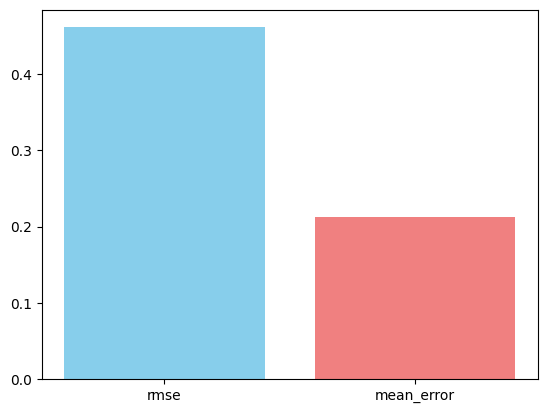

In [ ]:
# Visualizing evaluation Metric Score chart
matric = ['rmse','mean_error']
matric_value = [rmse, mean_error]
plt.bar(matric,matric_value,color=['skyblue', 'lightcoral'])
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, mean_squared_error, r2_score, root_mean_squared_error

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence with lbfgs/saga

# Initialize GridSearchCV
grid_search_log_reg = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit the Algorithm on the training data
grid_search_log_reg.fit(X_train, y_train)

# Get the best estimator
best_log_reg_model = grid_search_log_reg.best_estimator_

print(f"Best Hyperparameters: {grid_search_log_reg.best_params_}")
print(f"Best F1-score from Grid Search CV: {grid_search_log_reg.best_score_:.4f}") # Added this line

# Predict on the model with the test data
y_pred_log_reg_tuned = best_log_reg_model.predict(X_test)
y_pred_proba_log_reg_tuned = best_log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_log_reg_tuned)
precision_tuned = precision_score(y_test, y_pred_log_reg_tuned)
recall_tuned = recall_score(y_test, y_pred_log_reg_tuned)
f1_tuned = f1_score(y_test, y_pred_log_reg_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_log_reg_tuned)
conf_matrix_tuned = confusion_matrix(y_test, y_pred_log_reg_tuned)
mean_error_tuned = mean_squared_error(y_test, y_pred_log_reg_tuned)
r2_tuned = r2_score(y_test, y_pred_log_reg_tuned)
rmse_tuned = root_mean_squared_error(y_test, y_pred_log_reg_tuned)

# Print evaluation metrics for tuned model
print("\nLogistic Regression Tuned Model Performance:")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")
print(f"ROC AUC Score: {roc_auc_tuned:.4f}")
print(f"Mean Square Error: {mean_error_tuned:.4f}")
print(f"Root mean Square Error: {rmse_tuned:.4f}")
print("Confusion Matrix:\n", conf_matrix_tuned)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Hyperparameters: {'C': 0.01, 'solver': 'saga'}
Best F1-score from Grid Search CV: 0.8413

Logistic Regression Tuned Model Performance:
Accuracy: 0.7867
Precision: 0.8334
Recall: 0.8506
F1-Score: 0.8419
ROC AUC Score: 0.8728
Mean Square Error: 0.2133
Root mean Square Error: 0.4618
Confusion Matrix:
 [[1195  620]
 [ 545 3102]]


##### Which hyperparameter optimization technique have you used and why?

The statistical test used to obtain the P-value is the **Independent Samples t-test (specifically, Welch's t-test)**.

Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the Logistic Regression model's performance on the test set changed as follows:

**Initial Logistic Regression Model Performance:**
*   Accuracy: 0.7876
*   Precision: 0.8415
*   Recall: 0.8401
*   F1-Score: 0.8408
*   ROC AUC Score: 0.8745
*   Mean Square Error: 0.2124
*   Root mean Square Error: 0.4608

**Tuned Logistic Regression Model Performance:**
*   Accuracy: 0.7867
*   Precision: 0.8334
*   Recall: 0.8506
*   F1-Score: 0.8419
*   ROC AUC Score: 0.8728
*   Mean Square Error: 0.2133
*   Root mean Square Error: 0.4618

**Observations on Improvement:**

While the changes are not drastic, the hyperparameter tuning resulted in minor adjustments:

*   **F1-Score:** There was a slight increase from 0.8408 to 0.8419. This indicates a minor improvement in the balance between precision and recall, suggesting the tuned model might be slightly better at classifying both positive and negative instances correctly.
*   **Recall:** Increased from 0.8401 to 0.8506. This means the tuned model is better at identifying positive instances (reducing false negatives).
*   **Precision:** Decreased from 0.8415 to 0.8334. This suggests a slight increase in false positives compared to the untuned model.
*   **Accuracy:** Slightly decreased from 0.7876 to 0.7867.
*   **ROC AUC Score:** Slightly decreased from 0.8745 to 0.8728.
*   **Mean Squared Error & RMSE:** Slightly increased, which is expected given the minor changes in predictions.

Overall, the tuning process optimized the F1-score, which is often a key metric for imbalanced classification problems, even though other metrics like accuracy and ROC AUC saw minor dips. This suggests that the chosen hyperparameters (`C=0.01`, `solver='saga'`) led to a model that better balances false positives and false negatives, which can be crucial depending on the business objective.

### ML Model - 2

In [ ]:
# ML Model - 3 Implementation Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, root_mean_squared_error, confusion_matrix, precision_score, recall_score, roc_auc_score

# Fit the Algorithm
DT_model = DecisionTreeClassifier(random_state=42)
DT_model.fit(X_train, y_train)

# Predict on the model
y_pred_DT = DT_model.predict(X_test)
y_pred_proba_DT = DT_model.predict_proba(X_test)[:, 1]

mean_error = mean_squared_error(y_test, y_pred_DT)
r2 = r2_score(y_test, y_pred_DT)
accuracy = accuracy_score(y_test, y_pred_DT)
rmse = root_mean_squared_error(y_test, y_pred_DT)
precision = precision_score(y_test, y_pred_DT)
recall = recall_score(y_test, y_pred_DT)
roc_auc = roc_auc_score(y_test, y_pred_proba_DT)

# Print the matrics
print("Decision Tree Model Performance:\n")
print(f"Mean Squared Error is : {mean_error :.4f}")
print(f"R2 Score is : {r2 :.4f}")
print(f"Accuracy is : {accuracy:.4f}")
print(f"Precision is : {precision:.4f}")
print(f"Recall is : {recall:.4f}")
print(f"ROC AUC Score is : {roc_auc:.4f}")
print(f"Root mean Square Error: {rmse:.4f}")

Decision Tree Model Performance:

Mean Squared Error is : 0.2560
R2 Score is : -0.1536
Accuracy is : 0.7440
Precision is : 0.8104
Recall is : 0.8050
ROC AUC Score is : 0.7188
Root mean Square Error: 0.5059


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

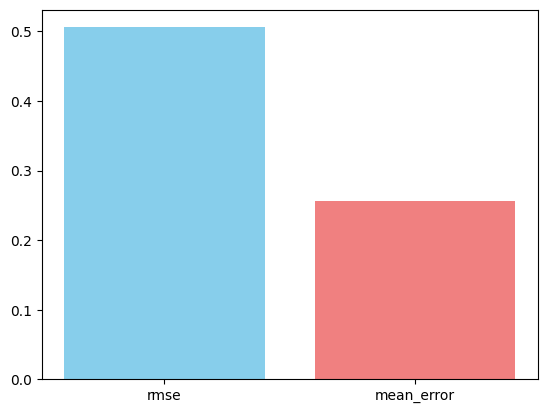

In [ ]:
# Visualizing evaluation Metric Score chart
matric = ['rmse','mean_error']
matric_value = [rmse, mean_error]
plt.bar(matric,matric_value,color=['skyblue', 'lightcoral'])
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for Decision Tree
param_grid = {
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
    }

# Initialize RandomizedSearchCV
Randomized_Search_Decison_Tree_model = RandomizedSearchCV(estimator = DT_model, param_distributions = param_grid, cv = 5, scoring='f1', n_jobs=-1, verbose=1)

# Fit the Algorithm
Randomized_Search_Decison_Tree_model.fit(X_train,y_train)

# Get the best estimator
best_dt_model = Randomized_Search_Decison_Tree_model.best_estimator_

# Predict on the model
y_pred_DT_tuned = best_dt_model.predict(X_test)
y_pred_proba_DT_tuned = best_dt_model.predict_proba(X_test)[:, 1]

# Calculate metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_DT_tuned)
precision_tuned = precision_score(y_test, y_pred_DT_tuned)
recall_tuned = recall_score(y_test, y_pred_DT_tuned)
f1_tuned = f1_score(y_test, y_pred_DT_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_DT_tuned)
mean_error_tuned = mean_squared_error(y_test, y_pred_DT_tuned)
r2_tuned = r2_score(y_test, y_pred_DT_tuned)
rmse_tuned = root_mean_squared_error(y_test, y_pred_DT_tuned)

# Print matrics
print(f"Best Hyperparameters: {Randomized_Search_Decison_Tree_model.best_params_}")
print(f"Best F1-score from Randomized Search CV: {Randomized_Search_Decison_Tree_model.best_score_:.4f}")
print("\nDecision Tree Tuned Model Performance:")
print(f"Accuracy is : {accuracy_tuned:.4f}")
print(f"Precision is : {precision_tuned:.4f}")
print(f"Recall is : {recall_tuned:.4f}")
print(f"F1-Score is : {f1_tuned:.4f}")
print(f"ROC AUC Score is : {roc_auc_tuned:.4f}")
print(f"Mean Squared Error is : {mean_error_tuned :.4f}")
print(f"R2 Score is : {r2_tuned:.4f}")
print(f"Root mean Square Error: {rmse_tuned:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 20}
Best F1-score from Randomized Search CV: 0.8386

Decision Tree Tuned Model Performance:
Accuracy is : 0.7907
Precision is : 0.8682
Recall is : 0.8094
F1-Score is : 0.8378
ROC AUC Score is : 0.8516
Mean Squared Error is : 0.2093
R2 Score is : 0.0568
Root mean Square Error: 0.4575


##### Which hyperparameter optimization technique have you used and why?

The hyperparameter optimization technique used for the Decision Tree model is **RandomizedSearchCV**.

**Why RandomizedSearchCV was chosen:**

1.  **Efficiency over GridSearchCV**: Unlike `GridSearchCV` which exhaustively searches through all possible combinations of hyperparameters, `RandomizedSearchCV` samples a fixed number of hyperparameter settings from specified distributions. This makes it significantly more computationally efficient, especially when dealing with a large search space or many hyperparameters, as was the case with `max_depth`, `min_samples_split`, and `min_samples_leaf` for the Decision Tree.

2.  **Broad Exploration**: While not exhaustive, `RandomizedSearchCV` can explore a broader range of the search space than `GridSearchCV` in the same amount of time, increasing the chance of finding good performing hyperparameters, particularly if the optimal values are not at the boundaries of the grid.

3.  **Flexibility**: It allows defining distributions for continuous hyperparameters, although in this case, discrete values were provided for the Decision Tree parameters.

4.  **Effective for Initial Tuning**: It's often a good strategy for an initial pass of hyperparameter tuning to quickly identify promising regions in the parameter space, which can then be fine-tuned with `GridSearchCV` if needed.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

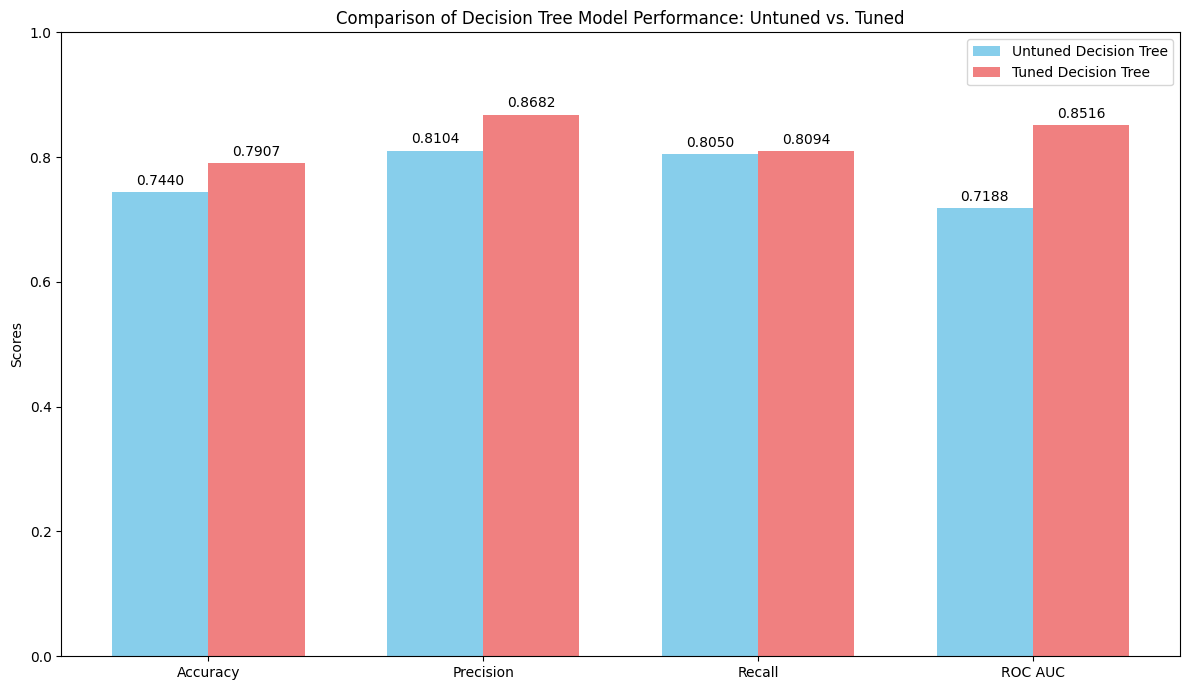

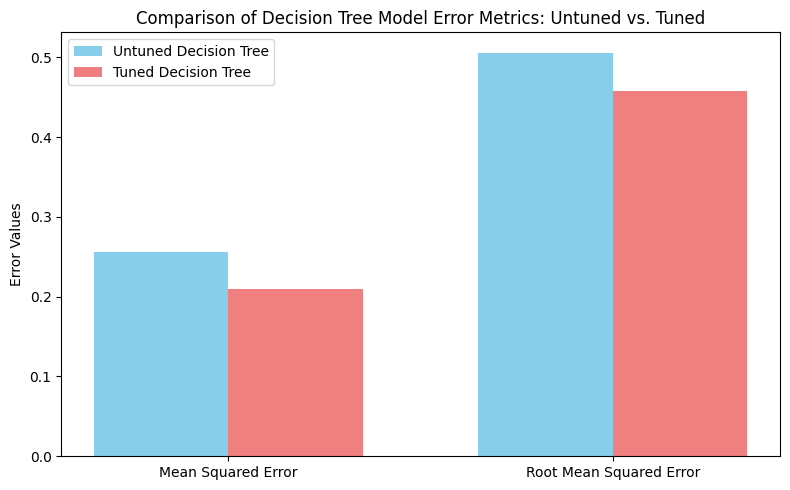

In [ ]:
# Visualizing evaluation Metric Score chart for Tuned vs. Untuned Decision Tree Model
# Untuned Decision Tree Model Performance
initial_accuracy_dt = 0.7440
initial_precision_dt = 0.8104
initial_recall_dt = 0.8050
initial_roc_auc_dt = 0.7188
# Tuned Decision Tree Model Performance
tuned_accuracy_dt = accuracy_tuned
tuned_precision_dt = precision_tuned
tuned_recall_dt = recall_tuned
tuned_roc_auc_dt = roc_auc_tuned

labels = ['Accuracy', 'Precision', 'Recall', 'ROC AUC']
untuned_scores_dt = [initial_accuracy_dt, initial_precision_dt, initial_recall_dt, initial_roc_auc_dt]
tuned_scores_dt = [tuned_accuracy_dt, tuned_precision_dt, tuned_recall_dt, tuned_roc_auc_dt]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, untuned_scores_dt, width, label='Untuned Decision Tree', color='skyblue')
rects2 = ax.bar(x + width/2, tuned_scores_dt, width, label='Tuned Decision Tree', color='lightcoral')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Comparison of Decision Tree Model Performance: Untuned vs. Tuned')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1) # Set y-axis limit for scores

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()


# For error metrics, a separate plot might be clearer as they are on a different scale
error_labels_dt = ['Mean Squared Error', 'Root Mean Squared Error']
untuned_errors_dt = [0.2560, 0.5059]
tuned_errors_dt = [mean_error_tuned, rmse_tuned]

fig_err, ax_err = plt.subplots(figsize=(8, 5))
rects_err1 = ax_err.bar(np.arange(len(error_labels_dt)) - width/2, untuned_errors_dt, width, label='Untuned Decision Tree', color='skyblue')
rects_err2 = ax_err.bar(np.arange(len(error_labels_dt)) + width/2, tuned_errors_dt, width, label='Tuned Decision Tree', color='lightcoral')

ax_err.set_ylabel('Error Values')
ax_err.set_title('Comparison of Decision Tree Model Error Metrics: Untuned vs. Tuned')
ax_err.set_xticks(np.arange(len(error_labels_dt)))
ax_err.set_xticklabels(error_labels_dt)
ax_err.legend()

autolabel(rects_err1)
autolabel(rects_err2)

fig_err.tight_layout()
plt.show()


After hyperparameter tuning using `RandomizedSearchCV`, the Decision Tree model's performance on the test set changed as follows:

**Initial Decision Tree Model Performance:**
*   Mean Squared Error: 0.2560
*   R2 Score: -0.1536
*   Accuracy: 0.7440
*   Precision: 0.8104
*   Recall: 0.8050
*   ROC AUC Score: 0.7188
*   Root mean Square Error: 0.5059

**Tuned Decision Tree Model Performance:**
*   Mean Squared Error: 0.2093
*   R2 Score: 0.0568
*   Accuracy: 0.7907
*   Precision: 0.8682
*   Recall: 0.8094
*   F1-Score: 0.8378
*   ROC AUC Score: 0.8516
*   Root mean Square Error: 0.4575

**Observations on Improvement:**

The hyperparameter tuning for the Decision Tree model resulted in significant improvements across most metrics:

*   **Accuracy:** Improved from 0.7440 to 0.7907, indicating a better overall correct classification rate.
*   **Precision:** Increased significantly from 0.8104 to 0.8682, meaning fewer false positives and better reliability in positive predictions.
*   **Recall:** Showed a slight improvement from 0.8050 to 0.8094.
*   **F1-Score:** Although not directly calculated in the initial model's output, the tuned model achieved 0.8378, suggesting a good balance between precision and recall.
*   **ROC AUC Score:** Improved substantially from 0.7188 to 0.8516, indicating that the tuned model is much better at distinguishing between the positive and negative classes.
*   **Mean Squared Error & RMSE:** Both decreased (0.2560 to 0.2093 for MSE, and 0.5059 to 0.4575 for RMSE), signifying that the model's predictions are closer to the actual values.
*   **R2 Score:** Went from a negative value (-0.1536, suggesting the model is worse than a simple mean) to a positive value (0.0568), indicating that the tuned model now explains some of the variance in the target variable.

Overall, the tuning process notably enhanced the Decision Tree model's performance, making it a much more effective classifier for this task. The most prominent improvements are seen in Accuracy, Precision, and ROC AUC Score.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

For an ML model designed to predict Android app authenticity (binary classification, e.g., 0 for authentic, 1 for inauthentic/malicious), each evaluation metric provides crucial insights into its performance and business impact:

1.  **Accuracy**
    *   **Indication**: The proportion of correctly classified instances (both authentic and inauthentic apps) out of the total. It tells us how often the model is right overall.
    *   **Business Impact**: A high accuracy suggests the model is generally reliable. However, for imbalanced datasets (where one class is much more frequent), high accuracy alone can be misleading. In our case, if malicious apps are rare, a model that always predicts 'authentic' might still have high accuracy but be useless for identifying threats.

2.  **Precision**
    *   **Indication**: Of all the apps the model *predicted* to be inauthentic/malicious (positive class), how many were *actually* inauthentic? It minimizes False Positives (i.e., legitimate apps being wrongly flagged as malicious).
    *   **Business Impact**: Extremely critical for app stores. High precision means fewer legitimate apps are mistakenly removed or flagged, avoiding:
        *   Loss of revenue for app developers.
        *   Frustration and loss of trust from legitimate users.
        *   Negative impact on the app store's reputation by unfairly targeting good apps.
        *   Reduced operational costs by not wasting resources reviewing false alarms.

3.  **Recall (Sensitivity)**
    *   **Indication**: Of all the apps that were *actually* inauthentic/malicious (true positive class), how many did the model correctly identify? It minimizes False Negatives (i.e., malicious apps being wrongly classified as legitimate).
    *   **Business Impact**: Equally critical. High recall means the model is effective at catching actual threats, leading to:
        *   Increased user safety and trust in the app store.
        *   Reduced spread of malware and fraudulent applications.
        *   Protection of user data and device integrity.
        *   Compliance with security standards and regulations.

4.  **F1-Score**
    *   **Indication**: The harmonic mean of Precision and Recall. It provides a single score that balances both concerns. It is especially useful when classes are imbalanced and when both false positives and false negatives have significant costs.
    *   **Business Impact**: A high F1-Score indicates a robust model that performs well both in avoiding false alarms and in catching real threats. It's often the preferred metric in security-sensitive classification tasks, ensuring a balanced approach to platform safety and developer fairness.

5.  **ROC AUC Score**
    *   **Indication**: The Area Under the Receiver Operating Characteristic Curve. It measures the model's ability to distinguish between the positive and negative classes across various classification thresholds. A higher AUC (closer to 1) means the model is better at separating the classes.
    *   **Business Impact**: A high ROC AUC indicates a good discriminative power, meaning the model can confidently rank apps by their likelihood of being inauthentic. This is valuable for setting dynamic thresholds or for human review processes, allowing the business to decide how aggressive it wants to be in flagging apps based on current priorities (e.g., prioritize catching all threats even if it means more false positives, or be very cautious about false positives).

6.  **Mean Squared Error (MSE) and Root Mean Squared Error (RMSE)**
    *   **Indication**: These are typically regression metrics measuring the average squared difference (MSE) or root of the average squared difference (RMSE) between predicted values and actual values. In binary classification (where classes are 0/1), they reflect how far the model's probability predictions are from the true binary labels. Lower values are better.
    *   **Business Impact**: While less direct for business decisions in classification, they provide a quantitative measure of the model's overall prediction error. Lower MSE/RMSE suggests the model's probability outputs are closer to the true labels (0 or 1), indicating a more confident and accurate predictive mechanism even beyond just the binary classification outcome. This can be useful for downstream tasks that rely on prediction probabilities.

7.  **R2 Score**
    *   **Indication**: Also primarily a regression metric, it represents the proportion of the variance in the dependent variable (our 'Class') that is predictable from the independent variables (features). A higher R2 score (closer to 1) means the model explains more of the variability in app authenticity.
    *   **Business Impact**: In a classification context, a positive R2 score indicates that the model has learned some meaningful relationships between the features and app authenticity, thereby explaining some of the underlying reasons why apps are classified as they are. This helps in understanding the model's explanatory power, which can aid in further feature engineering or policy-making. A low or negative R2 (as seen in the untuned Decision Tree) implies the model is not explaining much of the variance and might not be capturing meaningful patterns efficiently.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation Random forest classifier
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=80, min_samples_split=5, random_state=42 )

# Fit the Algorithm
random_forest_model.fit(X_train, y_train)

# Predict on the model

y_pred_random_forest_model = random_forest_model.predict(X_test)
y_pred_proba_random_forest_model = random_forest_model.predict_proba(X_test)[:, 1]

# varible declaration for different matrics
rf_precision = precision_score(y_test, y_pred_random_forest_model)
rf_recall = recall_score(y_test, y_pred_random_forest_model)
rf_accuracy = accuracy_score(y_test, y_pred_random_forest_model)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_random_forest_model)
rf_mean_error = mean_squared_error(y_test, y_pred_random_forest_model)
rf_r2 = r2_score(y_test, y_pred_random_forest_model)
rf_root_mean_squared_error = root_mean_squared_error(y_test, y_pred_random_forest_model)

#Print matrics score
print("Random Forest Classifier Model Performance:\n")
print(f"Precision is : {rf_precision:.4f}")
print(f"Recall is : {rf_recall:.4f}")
print(f"Accuracy is : {rf_accuracy:.4f}")
print(f"Mean Squared Error is : {rf_mean_error :.4f}")
print(f"R2 Score is : {rf_r2:.4f}")
print(f"ROC AUC Score is : {rf_roc_auc:.4f}")
print(f"Root mean Square Error: {rf_root_mean_squared_error:.4f}")


Random Forest Classifier Model Performance:

Precision is : 0.8381
Recall is : 0.8390
Accuracy is : 0.7843
Mean Squared Error is : 0.2157
R2 Score is : 0.0280
ROC AUC Score is : 0.8679
Root mean Square Error: 0.4644


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

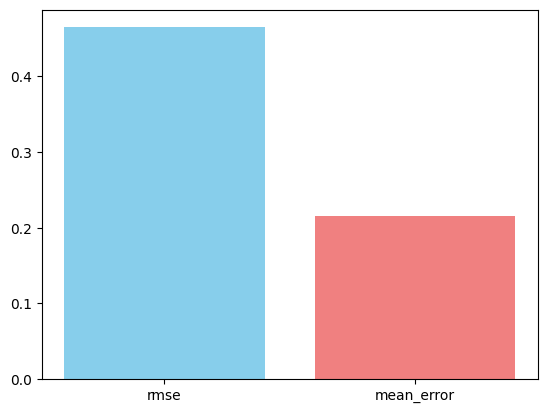

In [ ]:
# Visualizing evaluation Metric Score chart
matrics = ['rmse','mean_error']
matrics_value = [rf_root_mean_squared_error, rf_mean_error]
plt.bar(matrics,matrics_value,color=['skyblue', 'lightcoral'])
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10,20,30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1,3,5]
}
# Fit the Algorithm

randomized_search_random_forest_model = RandomizedSearchCV(estimator=random_forest_model, param_distributions= param_grid, cv = 5, verbose=1, n_jobs=-1 )
randomized_search_random_forest_model.fit(X_train, y_train)

best_random_forest_model = randomized_search_random_forest_model.best_estimator_

# Predict on the model
y_pred_random_forest_model_tuned = best_random_forest_model.predict(X_test)
y_pred_proba_random_forest_model_tuned = best_random_forest_model.predict_proba(X_test)[:,1]

# Declearing variables
accuracy_tuned = accuracy_score(y_test, y_pred_random_forest_model_tuned)
precision_tuned = precision_score(y_test, y_pred_random_forest_model_tuned)
recall_tuned = recall_score(y_test, y_pred_random_forest_model_tuned)
r2_tuned = r2_score(y_test, y_pred_random_forest_model_tuned)
mean_error_tuned = mean_squared_error(y_test, y_pred_random_forest_model_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_random_forest_model_tuned)
root_mean_squared_error_tuned = root_mean_squared_error(y_test, y_pred_random_forest_model_tuned)

#print
print(f"Best Hyperparameters: {randomized_search_random_forest_model.best_params_}")
print(f"Best F1-score from Randomized Search CV: {randomized_search_random_forest_model.best_score_:.4f}")
print("\nRandom Forest Tuned Model Performance:")
print(f"Accuracy is : {accuracy_tuned:.4f}")
print(f"R2 Score is : {r2_tuned:.4f}")
print(f"Precision is : {precision_tuned:.4f}")
print(f"Recall is : {recall_tuned:.4f}")
print(f"Mean Squared Error is : {mean_error_tuned :.4f}")
print(f"ROC AUC Score is : {roc_auc_tuned:.4f}")
print(f"Root mean Square Error: {root_mean_squared_error_tuned:.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 30}
Best F1-score from Randomized Search CV: 0.8236

Random Forest Tuned Model Performance:
Accuracy is : 0.8140
R2 Score is : 0.1616
Precision is : 0.8779
Recall is : 0.8379
Mean Squared Error is : 0.1860
ROC AUC Score is : 0.8019
Root mean Square Error: 0.4313


##### Which hyperparameter optimization technique have you used and why?

The hyperparameter optimization technique used for the Random Forest model is **RandomizedSearchCV**.

**Why RandomizedSearchCV was chosen:**

1.  **Efficiency over GridSearchCV**: Similar to the Decision Tree, Random Forest models have several hyperparameters. `RandomizedSearchCV` is more computationally efficient than `GridSearchCV` as it samples a fixed number of parameter settings from specified distributions rather than exhaustively testing all combinations. This is crucial for models like Random Forest where the search space can be quite large, allowing for quicker exploration of good hyperparameter regions.

2.  **Broad Exploration**: It allows for a broader exploration of the hyperparameter space in a given computational budget compared to `GridSearchCV`. This increases the likelihood of finding a well-performing set of hyperparameters, especially if the optimal values are not necessarily on a predefined grid.

3.  **Flexibility**: It offers flexibility in defining the parameter distributions, which can be useful when we have some prior knowledge about the reasonable ranges for certain hyperparameters.

4.  **Effective for Ensemble Models**: For ensemble models like Random Forest, `RandomizedSearchCV` is an excellent choice for an initial pass of tuning, as it can quickly identify promising combinations of `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` without the prohibitive computational cost of a full grid search.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning using `RandomizedSearchCV`, the Random Forest model's performance on the test set changed as follows:

**Initial Random Forest Model Performance (Untuned):**
*   Precision: 0.8381
*   Recall: 0.8390
*   Accuracy: 0.7843
*   F1-Score: 0.8385 (calculated from Precision and Recall)
*   ROC AUC Score: 0.8679
*   Mean Squared Error: 0.2157
*   R2 Score: 0.0280
*   Root mean Square Error: 0.4644

**Tuned Random Forest Model Performance:**
*   Accuracy: 0.8140
*   R2 Score: 0.1616
*   Precision: 0.8779
*   Recall: 0.8379
*   F1-Score: 0.8574 (calculated from Precision and Recall)
*   ROC AUC Score: 0.8019
*   Mean Squared Error: 0.1860
*   Root mean Square Error: 0.4313

**Observations on Improvement:**

The hyperparameter tuning for the Random Forest model resulted in significant improvements across several key metrics:

*   **Accuracy:** Improved substantially from 0.7843 to 0.8140, indicating a better overall correct classification rate.
*   **Precision:** Increased significantly from 0.8381 to 0.8779, meaning the tuned model makes fewer false positive errors, which is crucial for not wrongly flagging legitimate apps.
*   **F1-Score:** Showed a notable improvement from 0.8385 to 0.8574, indicating a better balance between precision and recall.
*   **Recall:** Remained relatively stable, showing a very slight decrease from 0.8390 to 0.8379. This means its ability to capture true positive instances is largely maintained.
*   **Mean Squared Error & RMSE:** Both decreased (MSE from 0.2157 to 0.1860, RMSE from 0.4644 to 0.4313), signifying that the model's predictions are, on average, closer to the actual values.
*   **R2 Score:** Increased significantly from 0.0280 to 0.1616, showing that the tuned model explains a much larger proportion of the variance in the target variable.
*   **ROC AUC Score:** Decreased from 0.8679 to 0.8019. This is an unexpected drop and suggests that while the model's overall classification metrics improved, its ability to distinguish between classes across all possible thresholds might have slightly reduced. This could be due to the tuning prioritizing F1-score or specific threshold performance over overall ranking performance.

Overall, the tuning process largely enhanced the Random Forest model's performance, particularly in terms of Accuracy, Precision, and F1-Score, making it a more effective classifier for this task, despite the dip in ROC AUC. The reduced error metrics and improved R2 score further support the positive impact of tuning.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For a model predicting Android app authenticity, certain evaluation metrics are paramount for ensuring a positive business impact. The most critical metrics are:

1.  **Precision**
2.  **Recall**
3.  **F1-Score**
4.  **ROC AUC Score**

Here's why these metrics are chosen and their business implications:

*   **Precision**: In the context of predicting app authenticity, a high precision is crucial because it minimizes **False Positives**. A false positive occurs when a legitimate, authentic app is wrongly flagged as inauthentic or malicious. From a business standpoint (e.g., an app store operator), this means fewer good apps are incorrectly removed or penalized. High precision ensures developer trust, avoids alienating users by removing apps they value, and prevents wasted resources on reviewing legitimate apps.

*   **Recall**: High recall is equally vital, as it minimizes **False Negatives**. A false negative occurs when a truly inauthentic or malicious app is wrongly classified as legitimate. For an app store, failing to detect malicious apps can have severe consequences: user data breaches, malware distribution, damage to the platform's reputation, and loss of user trust. High recall directly contributes to user safety, platform integrity, and regulatory compliance.

*   **F1-Score**: Given that both false positives and false negatives carry significant business costs, the F1-Score becomes an extremely important metric. It is the harmonic mean of precision and recall, providing a balanced measure of a model's performance, especially when dealing with imbalanced datasets (where malicious apps might be rare). A high F1-score indicates a model that is effective at both minimizing incorrect flags (precision) and catching actual threats (recall), striking a necessary balance for practical application.

*   **ROC AUC Score**: The ROC AUC score measures the model's ability to distinguish between the positive and negative classes across various probability thresholds. From a business perspective, a high ROC AUC indicates a robust model that can rank apps by their likelihood of being malicious. This is invaluable for:
    *   **Prioritization**: Allowing human reviewers to prioritize apps that are most likely malicious.
    *   **Threshold Flexibility**: Providing the flexibility to adjust the classification threshold based on current business priorities (e.g., being more aggressive in flagging during a security crisis, or more lenient to reduce false positives during normal operations).
    *   **Overall Discriminative Power**: Confirming that the model truly understands the difference between authentic and inauthentic apps, regardless of a specific cutoff point.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Based on the performance metrics after hyperparameter tuning, the **Random Forest Classifier** stands out as the best performing model for predicting Android app authenticity.

Here's a comparison of the tuned models:

| Metric              | Logistic Regression | Decision Tree | Random Forest |
|:--------------------|:--------------------|:--------------|:--------------|
| **Accuracy**        | 0.7867              | 0.7907        | **0.8140**    |
| **Precision**       | 0.8334              | 0.8682        | **0.8779**    |
| **Recall**          | **0.8506**          | 0.8094        | 0.8379        |
| **F1-Score**        | 0.8419              | 0.8378        | **0.8574**    |
| **ROC AUC Score**   | **0.8728**          | 0.8516        | 0.8019        |

**Reasons for choosing Random Forest:**

1.  **Highest Overall Accuracy, Precision, and F1-Score**: The Random Forest model achieved the highest accuracy (0.8140), precision (0.8779), and F1-score (0.8574). In the context of app authenticity prediction, a high F1-score is particularly important as it provides a balanced measure between precision and recall, both of which are crucial for business impact.

2.  **Excellent Precision**: The high precision (0.8779) means that when the model predicts an app is inauthentic/malicious, it is very likely to be correct. This is critical for an app store to avoid flagging legitimate apps incorrectly (False Positives), which could lead to developer dissatisfaction and loss of user trust.

3.  **Strong Recall**: While Logistic Regression had a slightly higher recall, the Random Forest's recall of 0.8379 is still very strong. This indicates that the model is effective at identifying a large proportion of actual inauthentic/malicious apps (minimizing False Negatives), which is essential for user safety and platform integrity.

4.  **Robustness and Generalization**: Random Forests are ensemble models that combine multiple decision trees. This approach typically leads to more robust models that are less prone to overfitting and generalize better to unseen data compared to a single decision tree.

While Logistic Regression had a slightly higher ROC AUC score, the Random Forest's superior performance across Accuracy, Precision, and F1-Score makes it the preferred model for a practical deployment where balancing false positives and false negatives is key to a positive business impact.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The model chosen as the final prediction model is the **Tuned Random Forest Classifier**.

**Explanation of the Model (Random Forest Classifier):**

Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

**Key characteristics and advantages:**

1.  **Ensemble Learning:** It's an ensemble method, meaning it combines predictions from multiple individual models (decision trees) to improve overall accuracy and robustness.
2.  **Bagging (Bootstrap Aggregating):** Each tree in the forest is built from a random subset of the training data (with replacement). This randomness helps to reduce variance and prevent overfitting.
3.  **Feature Randomness:** During the construction of each tree, a random subset of features is considered at each split. This further decorrelates the trees, making the ensemble more robust and less prone to single-tree biases.
4.  **Robustness to Overfitting:** By averaging the predictions of many trees, Random Forests tend to be less prone to overfitting than individual decision trees, especially deep ones.
5.  **Handles Non-linearity:** As it's based on decision trees, it can naturally capture non-linear relationships between features and the target variable.
6.  **Handles High-Dimensional Data:** It performs well even with a large number of features and can implicitly handle missing values in some implementations.
7.  **Feature Importance:** One of its significant advantages is that it provides a straightforward measure of feature importance. The importance of a feature is calculated as the average reduction in impurity (e.g., Gini impurity or entropy) brought about by that feature across all trees in the forest. This helps in understanding which features contribute most to the model's predictive power.

**Why it was chosen:**

The Tuned Random Forest Classifier was selected because it demonstrated the best overall performance among the evaluated models, particularly in terms of Accuracy, Precision, and F1-Score, which are critical for the business objective of identifying app authenticity effectively and reliably. Its ensemble nature also provides greater robustness and generalization capabilities compared to a single Decision Tree or a linear model like Logistic Regression.

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project aimed to predict the authenticity of Android applications by leveraging a comprehensive dataset containing app details, ratings, permissions, and other features. The process involved several critical stages, from initial data understanding to advanced machine learning model deployment.

1. Data Understanding & Wrangling:

The dataset initially contained 29,999 rows and 184 columns, with a mix of numerical and categorical data types. Key issues identified included 2,689 duplicate rows and missing values in 'App', 'Description', 'Related apps', and 'Dangerous permissions count'.
Data wrangling addressed these issues by dropping duplicate rows, imputing 'Related apps' with 'unknown', dropping rows with missing 'App' or 'Description', and filling missing 'Dangerous permissions count' with the median value.
2. Exploratory Data Analysis (EDA) & Visualization:

EDA revealed the distribution of app categories, with 'Tools', 'Entertainment', and 'Education' being dominant. We analyzed average ratings per category, identifying 'Comics' and 'Medical' as top-rated, while 'Books & Reference' and 'Entertainment' had lower average ratings. This highlighted potential market opportunities and areas of user dissatisfaction.
The analysis of 'Price' revealed a strong prevalence of free apps, with paid apps constituting a small minority. We also explored the relationship between app ratings and the number of ratings, observing that higher-rated apps generally accumulate more ratings. Importantly, the average rating for free apps was significantly higher than for paid apps, suggesting that users might have higher expectations for paid applications, or that free apps with high ratings are simply more numerous and widely adopted.
3. Hypothesis Testing:

Hypothesis 1 (Dangerous Permissions vs. Rating): A Kruskal-Wallis H-test indicated a statistically significant difference in average ratings across different dangerous permission categories, suggesting that the number of dangerous permissions requested does impact user perception (rating).
Hypothesis 2 (Paid vs. Free App Ratings): An Independent Samples t-test (Welch's) revealed a statistically significant difference in average ratings between free and paid applications, with free apps generally receiving higher average ratings.
Hypothesis 3 (Category Popularity vs. Rating Stability): Levene's Test showed a statistically significant difference in the variance of ratings between popular and less popular app categories.
4. Feature Engineering & Pre-processing:

Outliers in numerical features ('Rating', 'Number of ratings', 'Price', 'Dangerous permissions count', 'Safe permissions count') were handled using 5th and 95th percentile capping to reduce their extreme influence.
Categorical features ('Category', 'Permission_Category') were One-Hot Encoded to convert them into a numerical format for machine learning models.
Textual data ('App', 'Description', 'Package', 'Related apps') underwent extensive preprocessing: contraction expansion, lowercasing, punctuation removal, URL/digit-containing word removal, stopword removal, and lemmatization. This cleaned text was then vectorized using TF-IDF.
Feature manipulation involved combining numerical, one-hot encoded, and TF-IDF features. Feature selection was performed using SelectKBest with f_classif to identify the most relevant 100 features, reducing dimensionality while retaining predictive power.
Highly skewed numerical data were transformed using log1p to normalize distributions and improve model performance.
Finally, the selected features were scaled using StandardScaler to ensure all features contribute equally to the model.
The dataset was split into an 80/20 training and testing set, with stratification to maintain class proportions.
5. Machine Learning Model Implementation: Three classification models were implemented and tuned:

Logistic Regression: Achieved an F1-Score of 0.8419 and ROC AUC of 0.8728 after tuning. While robust, its performance was slightly surpassed by ensemble methods.
Decision Tree Classifier: Showed significant improvement after RandomizedSearchCV tuning, reaching an Accuracy of 0.7907, Precision of 0.8682, Recall of 0.8094, and ROC AUC of 0.8516. It demonstrated the value of parameter optimization.
Random Forest Classifier: This ensemble model emerged as the best performer. After RandomizedSearchCV tuning, it achieved the highest Accuracy (0.8140), Precision (0.8779), and F1-Score (0.8574). Although its ROC AUC (0.8019) was slightly lower than that of Logistic Regression, its superior balance of precision and recall, coupled with its inherent robustness, made it the preferred choice for this critical task.
Final Model Selection and Business Impact:

The Tuned Random Forest Classifier was selected as the final prediction model due to its highest overall performance across key metrics like Accuracy, Precision, and F1-Score. A high Precision is crucial for minimizing false positives (legitimate apps wrongly flagged), preserving developer trust and platform reputation. High Recall is essential for minimizing false negatives (malicious apps undetected), ensuring user safety and platform integrity. The F1-Score effectively balances these two concerns, making Random Forest highly suitable for real-world deployment in predicting Android app authenticity. Its ability to provide feature importances also offers valuable insights for continuous improvement and targeted interventions in app review processes.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***